# Проработка и описание MFT стратегии

## Предобработка данных

### Скачивание данных

In [ ]:
import time
import requests
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

# Платная подписка за 30$ (да, я специально ради домашки по MFT купил)
TIINGO_API_KEY = "<API-KEY>"

START_DATE = "2017-01-01"
END_DATE   = "2025-12-31"
CSV_PATH   = "equity_project/data/pony/S&P_500_Historical_Components.csv"
OUT_PATH   = "equity_project/data/raw/all_data.parquet"

DELAY_SECS = 0.1

In [ ]:
def get_sp500_tickers(csv_path: str, start_date: str) -> list[str]:
    """Возвращает отсортированный список тикеров, входивших в S&P 500 начиная с start_date.

    Args:
        csv_path:   Путь до S&P_500_Historical_Components.csv.
        start_date: Дата начала в формате YYYY-MM-DD. Тикеры, ушедшие из индекса
                    до этой даты, игнорируются.

    Returns:
        Отсортированный список тикеров.
    """
    historical = pd.read_csv(csv_path, index_col=0)
    historical.index = pd.to_datetime(historical.index)
    historical = historical[historical.index >= start_date]

    tickers: set[str] = set()
    for row in historical["tickers"]:
        for t in row.split(","):
            tickers.add(t.strip())

    for old, new in [("BF.B", "BF-B"), ("BRK.B", "BRK-B")]:
        if old in tickers:
            tickers.discard(old)
            tickers.add(new)

    return sorted(tickers)


def fetch_ticker(
    ticker: str,
    start: str,
    end: str,
    session: requests.Session,
) -> pd.DataFrame | None:
    """Скачивает скорректированные дневные OHLCV для одного тикера с Tiingo.

    Args:
        ticker:  Тикер бумаги.
        start:   Начальная дата в формате YYYY-MM-DD.
        end:     Конечная дата в формате YYYY-MM-DD.
        session: requests.Session с выставленным Authorization-заголовком.

    Returns:
        DataFrame с колонками [Open, High, Low, Close, Volume] и DatetimeIndex,
        или None при любой ошибке.
    """
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {"startDate": start, "endDate": end, "format": "json"}

    try:
        resp = session.get(url, params=params, timeout=15)
    except requests.exceptions.Timeout:
        tqdm.write(f"  [timeout] {ticker}")
        return None
    except requests.exceptions.ConnectionError:
        tqdm.write(f"  [conn err] {ticker}")
        return None

    if resp.status_code != 200:
        tqdm.write(f"  [HTTP {resp.status_code}] {ticker}: {resp.text[:120]}")
        return None

    data = resp.json()
    if not data:
        tqdm.write(f"  [empty] {ticker}: нет данных за {start}–{end}")
        return None

    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None).dt.normalize()
    df = df.set_index("date")
    df.index.name = "Date"
    df = df[["adjOpen", "adjHigh", "adjLow", "adjClose", "adjVolume"]].rename(columns={
        "adjOpen": "Open", "adjHigh": "High", "adjLow": "Low",
        "adjClose": "Close", "adjVolume": "Volume",
    })
    return df.astype(float)


tickers = get_sp500_tickers(CSV_PATH, START_DATE)
print(f"Тикеров для скачивания: {len(tickers)}")

In [21]:
# Быстрая проверка ключа и соединения на одном тикере
_test_session = requests.Session()
_test_session.headers.update({
    "Content-Type":  "application/json",
    "Authorization": f"Token {TIINGO_API_KEY}",
})

_df = fetch_ticker("AAPL", "2024-01-01", "2024-01-10", _test_session)
if _df is not None:
    print(f"OK — получено {len(_df)} строк для AAPL")
    display(_df)
else:
    print("Не удалось получить данные — смотри сообщения выше")

OK — получено 7 строк для AAPL


,Open,High,Low,Close,Volume
Date,,,,,
2024-01-02,185.237934,186.514754,182.006292,183.743361,82488674.0
2024-01-03,182.337869,183.980909,181.555940,182.367562,58414460.0
2024-01-04,180.289018,181.216643,179.031993,180.051470,71983570.0
2024-01-05,180.130652,180.892785,178.329247,179.328928,62196924.0
2024-01-08,180.224682,183.703770,179.645659,183.664179,59144470.0
2024-01-09,182.040934,183.258367,180.863092,183.248470,42841809.0
2024-01-10,182.466541,184.495596,182.040934,184.287742,46792908.0


In [22]:
session = requests.Session()
session.headers.update({
    "Content-Type":  "application/json",
    "Authorization": f"Token {TIINGO_API_KEY}",
})

results: dict[str, pd.DataFrame] = {}
failed:  list[str] = []

for ticker in tqdm(tickers, desc="Скачивание OHLCV с Tiingo"):
    df = fetch_ticker(ticker, START_DATE, END_DATE, session)
    if df is not None:
        results[ticker] = df
    else:
        failed.append(ticker)

print(f"\nУспешно скачано : {len(results)} тикеров")
print(f"Не найдено      : {len(failed)} тикеров")
if failed:
    print("Failed:", failed[:30], ("..." if len(failed) > 30 else ""))

Скачивание OHLCV с Tiingo:   0%|          | 0/703 [00:00<?, ?it/s]

  [empty] ABC: нет данных за 2017-01-01–2025-12-31
  [empty] ADS: нет данных за 2017-01-01–2025-12-31
  [empty] ANTM: нет данных за 2017-01-01–2025-12-31
  [empty] APC: нет данных за 2017-01-01–2025-12-31
  [empty] BLL: нет данных за 2017-01-01–2025-12-31
  [HTTP 404] CBS: {"detail":"Error: Ticker 'CBS' not found"}
  [HTTP 404] CDAY: {"detail":"Error: Ticker 'CDAY' not found"}
  [empty] COG: нет данных за 2017-01-01–2025-12-31
  [HTTP 404] ENDP: {"detail":"Error: Ticker 'ENDP' not found"}
  [empty] FBHS: нет данных за 2017-01-01–2025-12-31
  [empty] FLT: нет данных за 2017-01-01–2025-12-31
  [HTTP 404] FRC: {"detail":"Error: Ticker 'FRC' not found"}
  [empty] GPS: нет данных за 2017-01-01–2025-12-31
  [HTTP 404] HFC: {"detail":"Error: Ticker 'HFC' not found"}
  [empty] MMC: нет данных за 2017-01-01–2025-12-31
  [HTTP 404] MNK: {"detail":"Error: Ticker 'MNK' not found"}
  [empty] PEAK: нет данных за 2017-01-01–2025-12-31
  [empty] PKI: нет данных за 2017-01-01–2025-12-31
  [empty] RE: н

In [23]:
price_types = ["Open", "High", "Low", "Close", "Volume"]
wide = pd.concat(
    {pt: pd.DataFrame({t: results[t][pt] for t in results}) for pt in price_types},
    axis=1,
)
wide.columns.names = ["Price", "Ticker"]
wide = wide.sort_index(axis=1)
wide.index = pd.to_datetime(wide.index)

out = Path("equity_project/data/raw/")
out.mkdir(parents=True, exist_ok=True)
wide.to_csv(out / "all_data.csv")
print(f"Сохранено: {out / 'all_data.csv'}  ({wide.shape})")

Сохранено: equity_project/data/raw/all_data.csv  ((2262, 3405))


### Просмотр датасета с tiingo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

all_data = pd.read_csv(
    "equity_project/data/raw/all_data.csv",
    index_col=0,
    header=[0, 1],
)
all_data.index = pd.to_datetime(all_data.index)
all_data.index.name = "Date"
close  = all_data["Close"]
volume = all_data["Volume"]

print(f"Shape:         {all_data.shape}")
print(f"Период:        {all_data.index.min().date()} — {all_data.index.max().date()}")
print(f"Торговых дней: {len(all_data)}")
print(f"Price types:   {all_data.columns.get_level_values(0).unique().tolist()}")
print(f"Тикеров:       {all_data.columns.get_level_values(1).nunique()}")
print(f"Columns:       MultiIndex {all_data.columns.names}")
print()

sample_tickers = ["AAPL", "MSFT", "AMZN"]
all_data.loc[:, (slice(None), sample_tickers)].head(3)

Shape:         (2262, 3405)
Период:        2017-01-03 — 2025-12-31
Торговых дней: 2262
Price types:   ['Close', 'High', 'Low', 'Open', 'Volume']
Тикеров:       681
Columns:       MultiIndex ['Price', 'Ticker']



Price,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,MSFT,MSFT,MSFT,MSFT,MSFT,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,,,,,,,,,,
2017-01-03,26.745098,26.786545,26.425032,26.664506,115127460.0,56.166149,56.399502,55.757782,56.354626,20694101.0,37.6835,37.937975,37.385000,37.8960,70421320.0
2017-01-04,26.715164,26.827993,26.652993,26.676019,84472464.0,55.914846,56.318726,55.753295,56.076398,21339969.0,37.8590,37.984000,37.710000,37.9195,50210520.0
2017-01-05,26.851019,26.909552,26.666808,26.692137,88774348.0,55.914846,56.237950,55.672519,55.816120,24875968.0,39.0225,39.119995,38.012785,38.0775,116601360.0


,total_cells,nan_count,nan_pct,tickers_with_any_nan,tickers_always_nan,tickers_fully_present
price_type,,,,,,
Close,1540422,149206,9.7,134,0,547
High,1540422,149206,9.7,134,0,547
Low,1540422,149206,9.7,134,0,547
Open,1540422,149206,9.7,134,0,547
Volume,1540422,149206,9.7,134,0,547


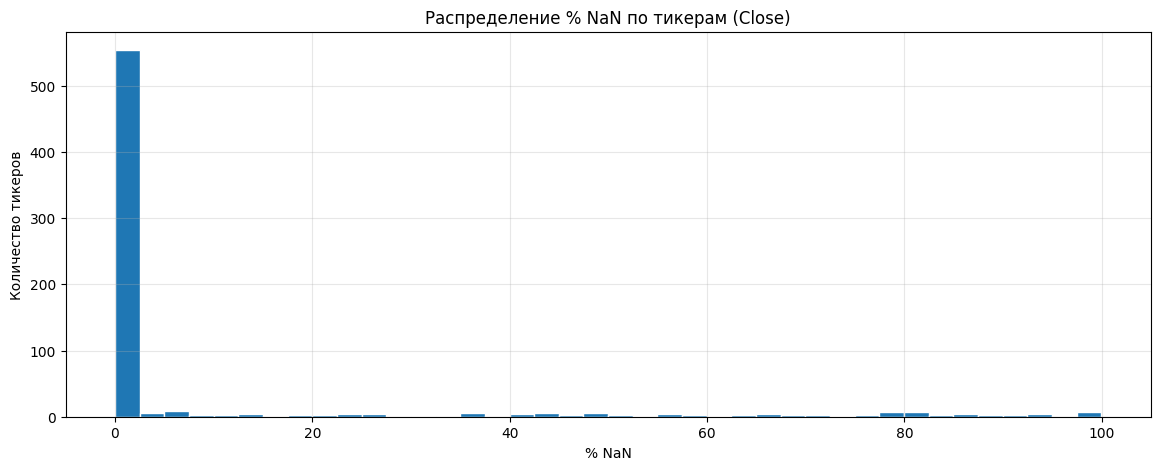

In [11]:
# NaN-статистика по каждому типу цены
nan_rows = []
for pt in all_data.columns.get_level_values(0).unique():
    df_pt = all_data[pt]
    nan_rows.append({
        "price_type": pt,
        "total_cells": df_pt.size,
        "nan_count": int(df_pt.isna().sum().sum()),
        "nan_pct": round(df_pt.isna().mean().mean() * 100, 1),
        "tickers_with_any_nan": int(df_pt.isna().any().sum()),
        "tickers_always_nan": int(df_pt.isna().all().sum()),
        "tickers_fully_present": int((~df_pt.isna().any()).sum()),
    })

nan_by_type = pd.DataFrame(nan_rows).set_index("price_type")
display(nan_by_type)

# Распределение доли NaN по тикерам (Close)
nan_per_ticker = close.isna().mean() * 100


fig, ax = plt.subplots()
ax.hist(nan_per_ticker, bins=40, edgecolor="white")
ax.set_title("Распределение % NaN по тикерам (Close)")
ax.set_xlabel("% NaN")
ax.set_ylabel("Количество тикеров")

None

### Анализ полученных данных

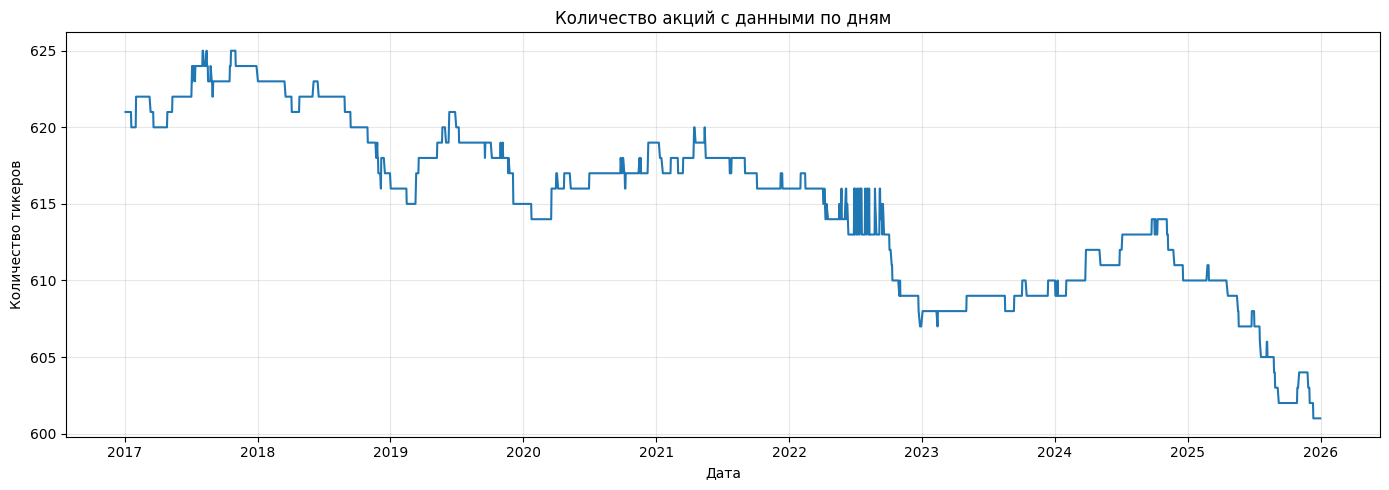

In [12]:
# Количество активных акций на каждую дату
active_count = close.notna().sum(axis=1)

fig, ax = plt.subplots()
ax.plot(active_count.index, active_count.values)
ax.set_title("Количество акций с данными по дням")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество тикеров")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

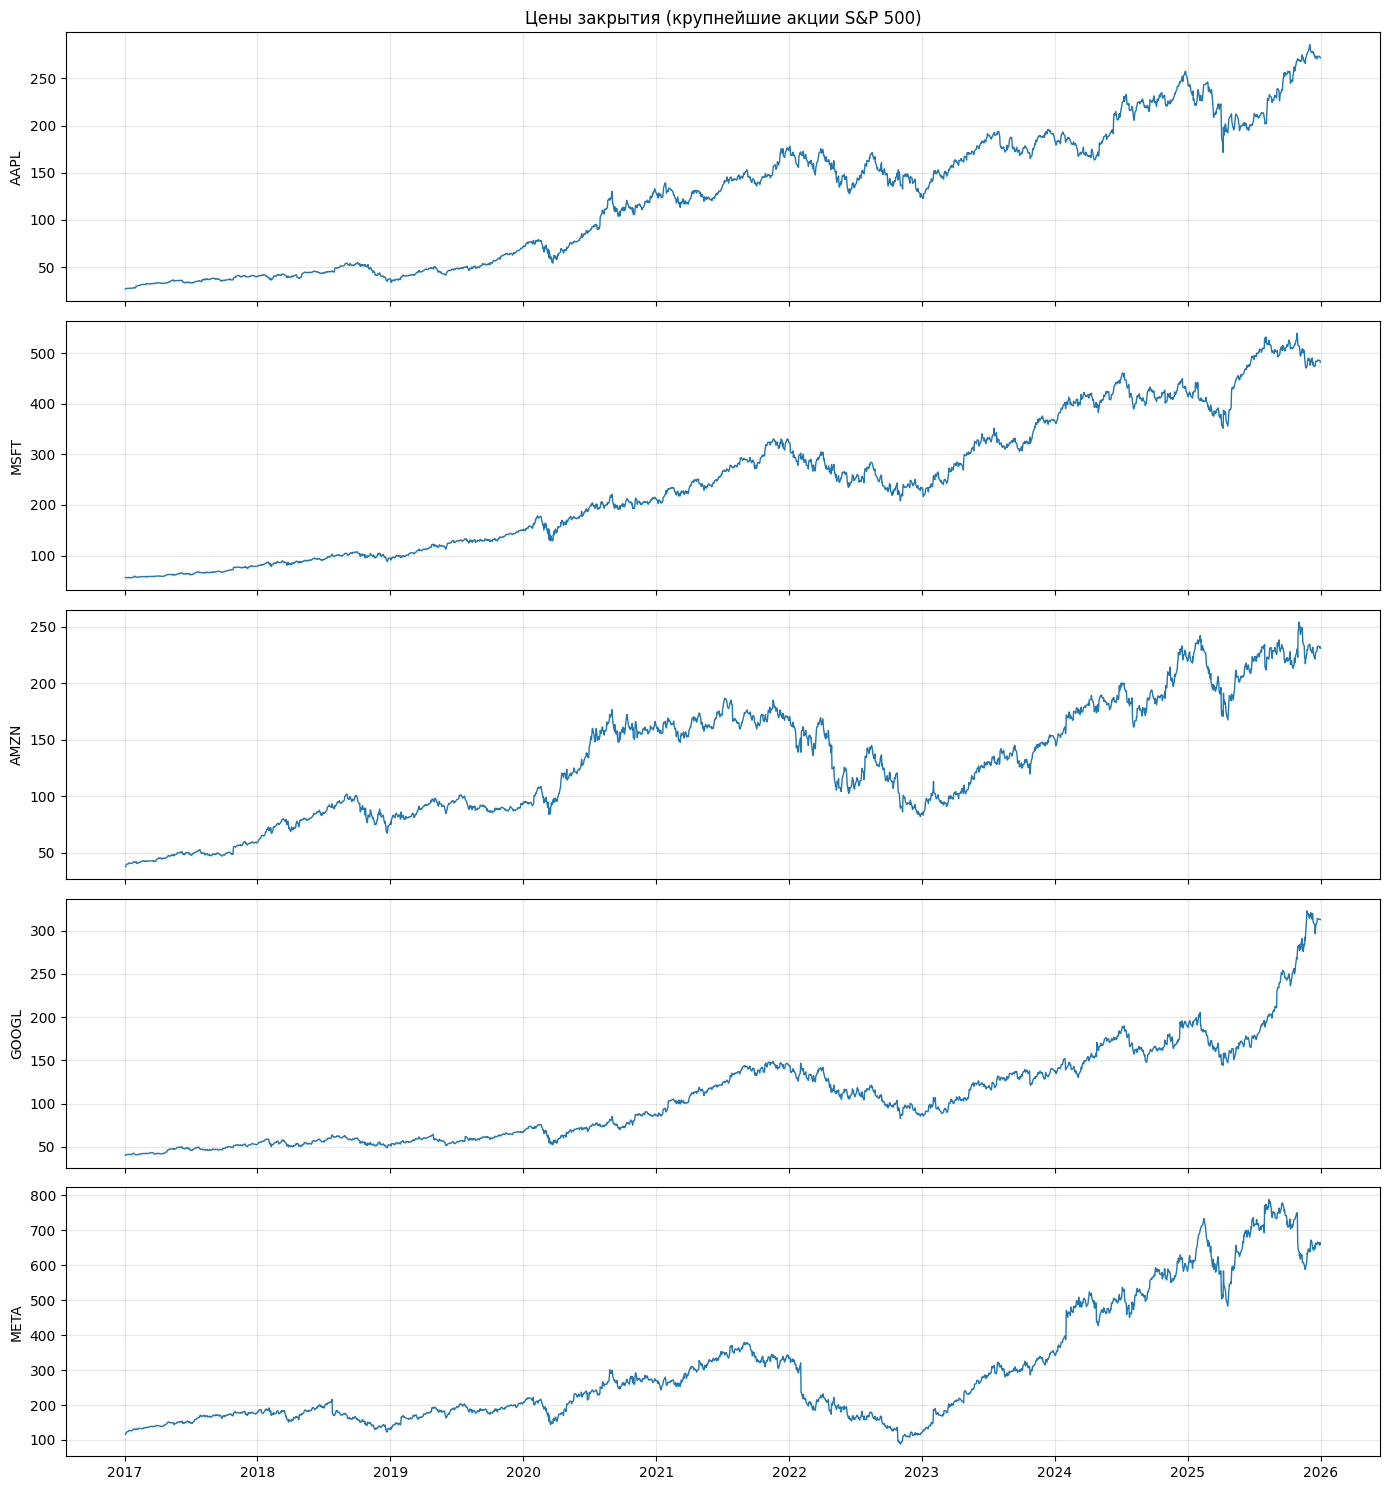

In [13]:
# Цены закрытия для нескольких крупных акций
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
tickers = [t for t in tickers if t in close.columns]

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 3 * len(tickers)), sharex=True)
for ax, ticker in zip(axes, tickers):
    ax.plot(close.index, close[ticker], linewidth=1)
    ax.set_ylabel(ticker)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_title("Цены закрытия (крупнейшие акции S&P 500)")
plt.tight_layout()
plt.show()

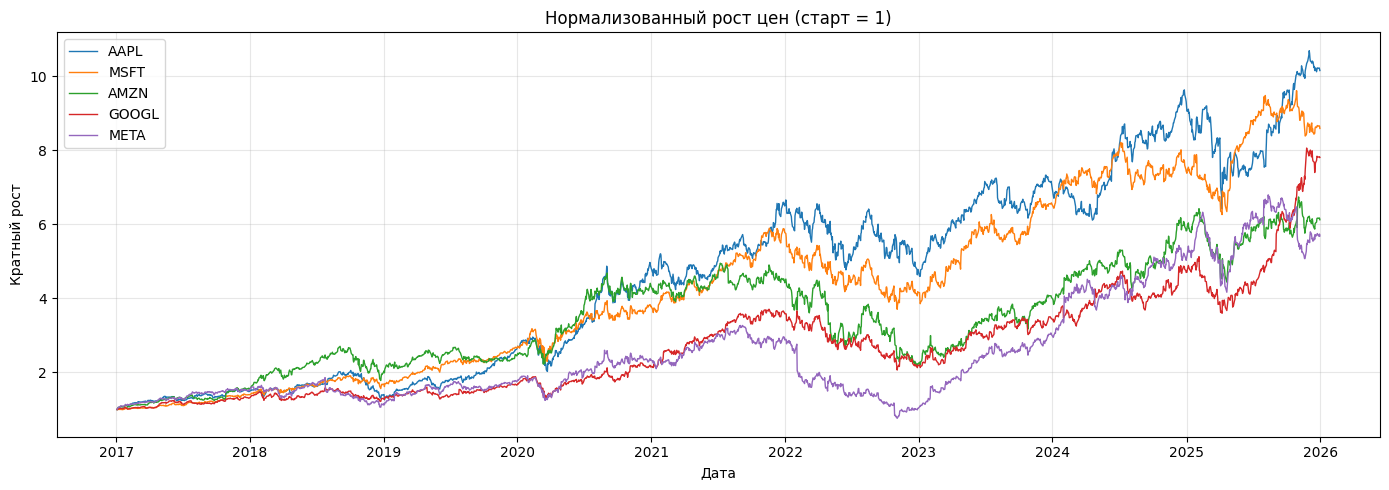

In [14]:
# Нормализованные цены (base = 1 на старте)
base_tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
base_tickers = [t for t in base_tickers if t in close.columns]
normed = close[base_tickers].dropna(how="all")
normed = normed.div(normed.iloc[0])

fig, ax = plt.subplots()
for ticker in base_tickers:
    ax.plot(normed.index, normed[ticker], label=ticker, linewidth=1)
ax.set_title("Нормализованный рост цен (старт = 1)")
ax.set_xlabel("Дата")
ax.set_ylabel("Кратный рост")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.show()

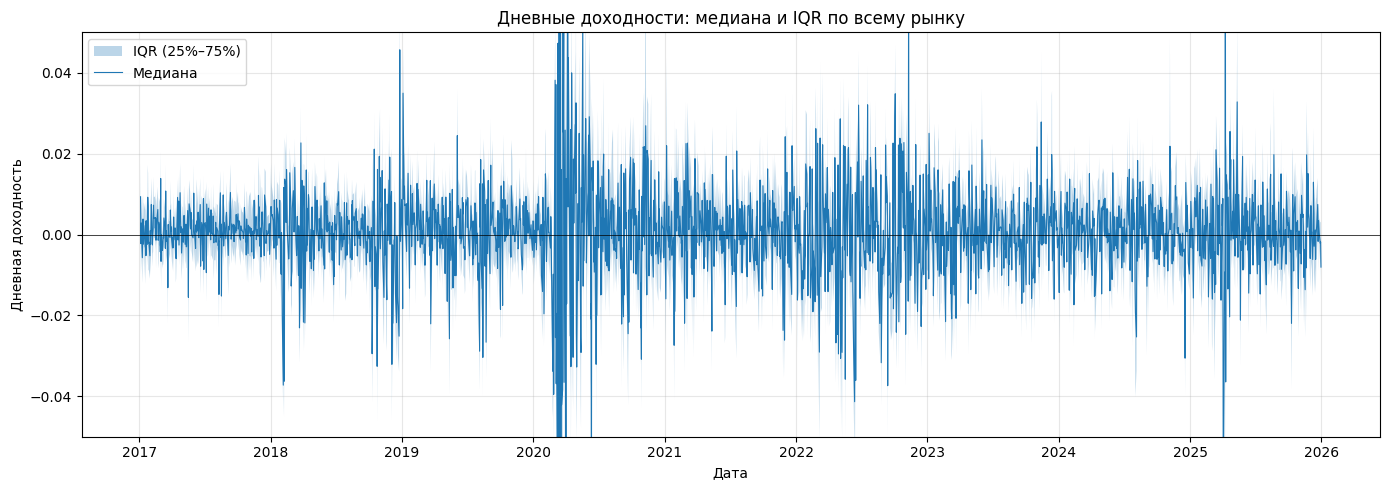

In [16]:
# Дневные доходности: медиана и межквартильный диапазон по всем акциям
returns = close.pct_change().dropna(how="all")

median_ret = returns.median(axis=1)
q25 = returns.quantile(0.25, axis=1)
q75 = returns.quantile(0.75, axis=1)

fig, ax = plt.subplots()
ax.fill_between(returns.index, q25, q75, alpha=0.3, label="IQR (25%–75%)")
ax.plot(returns.index, median_ret, linewidth=0.8, label="Медиана")
ax.set_ylim(-0.05, 0.05)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Дневные доходности: медиана и IQR по всему рынку")
ax.set_xlabel("Дата")
ax.set_ylabel("Дневная доходность")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.show()

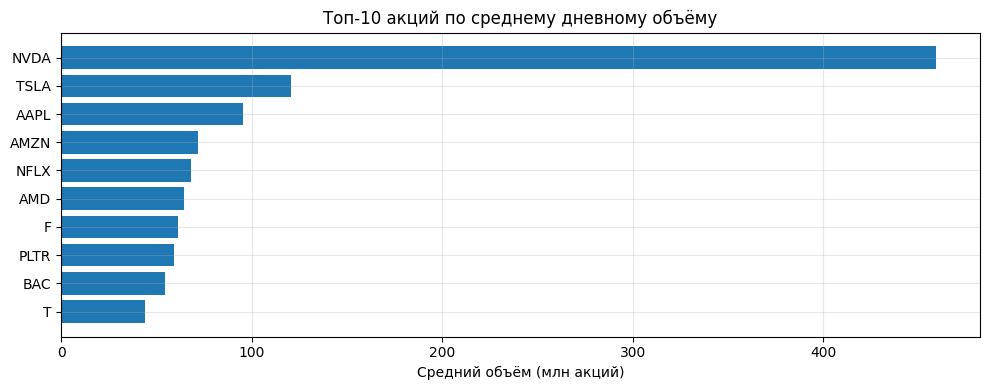

In [17]:
# Средний дневной объём торгов (топ-10 по объёму)
avg_volume = volume.mean().sort_values(ascending=False)
top10 = avg_volume.head(10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top10.index[::-1], top10.values[::-1] / 1e6)
ax.set_title("Топ-10 акций по среднему дневному объёму")
ax.set_xlabel("Средний объём (млн акций)")
plt.tight_layout()
plt.show()

### Фильтрация данных

In [ ]:
from pathlib import Path

# Тикеры без единого пропуска в Close за весь период
complete_tickers = close.columns[close.notna().all()].tolist()

print(f"Тикеров до фильтрации:  {close.shape[1]}")
print(f"Тикеров после:          {len(complete_tickers)}")
print(f"Отброшено:              {close.shape[1] - len(complete_tickers)}")

# Фильтруем все price type для полных тикеров — all_data/close/volume не трогаем
all_data_filtered = all_data.loc[:, (slice(None), complete_tickers)]

Path("equity_project/data/processed").mkdir(parents=True, exist_ok=True)
all_data_filtered.to_csv("equity_project/data/processed/all_data.csv")
print(f"\nСохранено: equity_project/data/processed/all_data.csv  {all_data_filtered.shape}")

### Выбор таргетов для предсказания

Мы используем два таргета, которые описывают разные аспекты будущего движения акции.

**Таргет 1 — Triple Barrier** отвечает на вопрос: *куда двинется акция быстрее — вверх, вниз, или никуда?* Для каждой точки t смотрим вперёд на `N_DAYS` дней и фиксируем какой барьер пробит первым:
- Верхний (`+BARRIER_PCT`) → метка **+1** (лонг)
- Нижний (`-BARRIER_PCT`) → метка **-1** (шорт)
- Ни один → метка **0** (нейтрал)

**Таргет 2 — квантиль доходности** отвечает на вопрос: *лучше или хуже эта акция остальных через N дней?* Считаем форвардную доходность за `N_DAYS` дней, вискоризируем (обрезаем хвосты), затем ранжируем по всем акциям на каждую дату и делим на 5 бинов:
- квантиль 1 — худшие 20%
- квантиль 5 — лучшие 20%

Оба таргета используют горизонт `N_DAYS = 22` торговых дня (~1 месяц).

In [22]:
import numpy as np

# Загружаем отфильтрованные данные из processed
all_data_filtered = pd.read_csv(
    "equity_project/data/processed/all_data.csv",
    index_col=0,
    header=[0, 1],
)
all_data_filtered.index = pd.to_datetime(all_data_filtered.index)
close_clean = all_data_filtered["Close"]

N_DAYS      = 22      # горизонт: ~1 месяц
BARRIER_PCT = 0.05    # ±5% для triple barrier

print(f"Тикеров: {close_clean.shape[1]}, дней: {close_clean.shape[0]}")

Тикеров: 547, дней: 2262


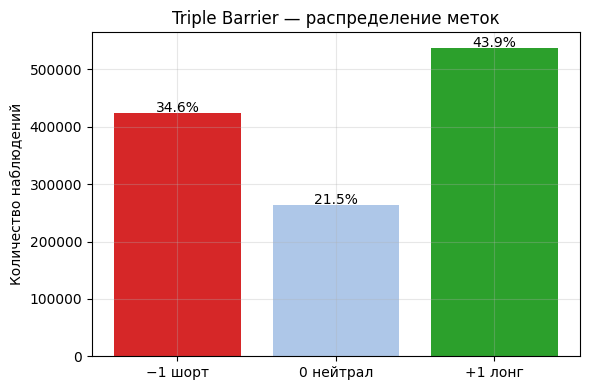

In [23]:
def compute_triple_barrier(
    close: pd.DataFrame,
    n_days: int,
    barrier_pct: float,
) -> pd.DataFrame:
    """Размечает каждую (дата, тикер) тройным барьером.

    Для точки t смотрим вперёд n_days дней и определяем какой барьер
    пробит первым: верхний (+barrier_pct), нижний (-barrier_pct)
    или вертикальный (время вышло).

    Args:
        close:       DataFrame цен закрытия (Date × Ticker).
        n_days:      Ширина окна в торговых днях.
        barrier_pct: Размер горизонтальных барьеров (доля от цены).

    Returns:
        DataFrame меток {-1, 0, +1} той же формы, что close.
        Последние n_days строк — NaN (нет форвардного окна).
    """
    arr = close.values.astype(float)   # (T, N)
    T, N = arr.shape
    labels = np.full((T, N), np.nan)

    for i in range(T - n_days):
        p0 = arr[i]                        # (N,) — цены сегодня
        window = arr[i + 1: i + n_days + 1]  # (n_days, N)
        ret = window / p0 - 1              # форвардные доходности

        upper = ret >= barrier_pct
        lower = ret <= -barrier_pct

        # argmax возвращает первый True; если нет True — ставим n_days (вне окна)
        first_up = np.where(upper.any(axis=0), upper.argmax(axis=0), n_days)
        first_dn = np.where(lower.any(axis=0), lower.argmax(axis=0), n_days)

        label = np.where(first_up < first_dn,  1.0,
                np.where(first_dn < first_up, -1.0, 0.0))
        label[np.isnan(p0)] = np.nan
        labels[i] = label

    return pd.DataFrame(labels, index=close.index, columns=close.columns)


tb = compute_triple_barrier(close_clean, N_DAYS, BARRIER_PCT)

# Распределение меток (по всем тикерам и датам, без NaN)
counts = tb.stack().value_counts().sort_index()
counts.index = counts.index.map({-1: "−1 шорт", 0: "0 нейтрал", 1: "+1 лонг"})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=["#d62728", "#aec7e8", "#2ca02c"])
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"{val / counts.sum():.1%}", ha="center", fontsize=10)
ax.set_title("Triple Barrier — распределение меток")
ax.set_ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

In [25]:
def compute_quintile(close: pd.DataFrame, n_days: int) -> pd.DataFrame:
    """Размечает каждую (дата, тикер) квинтилем кросс-секционной доходности.

    Для каждой даты t считаем форвардную доходность за n_days дней,
    вискоризируем на уровне [1%, 99%], ранжируем по всем тикерам и
    делим на 5 равных бинов (1 = худшие 20%, 5 = лучшие 20%).

    Args:
        close:  DataFrame цен закрытия (Date × Ticker).
        n_days: Горизонт прогнозирования в торговых днях.

    Returns:
        DataFrame квинтилей {1, 2, 3, 4, 5} той же формы, что close.
        Последние n_days строк — NaN (нет форвардного окна).
    """
    # форвардная доходность: смотрим на n_days дней вперёд
    fwd_ret = close.shift(-n_days) / close - 1   # (T, N)

    # вискоризация по каждой дате (строке): обрезаем хвосты [1%, 99%]
    lo = fwd_ret.quantile(0.01, axis=1)
    hi = fwd_ret.quantile(0.99, axis=1)
    fwd_ret_clipped = fwd_ret.clip(lower=lo, upper=hi, axis=0)

    # кросс-секционный ранг → 5 бинов
    ranks = fwd_ret_clipped.rank(axis=1, pct=True)  # 0..1
    quintile = (ranks * 5).apply(np.floor).clip(upper=4) + 1   # 1..5

    # последние n_days строк не имеют форвардного окна
    quintile.iloc[-n_days:] = np.nan

    return quintile


quintile = compute_quintile(close_clean, N_DAYS)

In [26]:
# Добавляем таргеты к датасету как новые "price types"
tb_wide = pd.concat({"TripleBarrier": tb}, axis=1)
tb_wide.columns.names = ["Price", "Ticker"]

q_wide = pd.concat({"Quintile": quintile}, axis=1)
q_wide.columns.names = ["Price", "Ticker"]

all_data_labeled = pd.concat([all_data_filtered, tb_wide, q_wide], axis=1)
all_data_labeled = all_data_labeled.sort_index(axis=1)

out_path = Path("equity_project/data/processed/all_data_labeled.csv")
all_data_labeled.to_csv(out_path)

print(f"Сохранено: {out_path}  {all_data_labeled.shape}")
print(f"Price types: {all_data_labeled.columns.get_level_values('Price').unique().tolist()}")

Сохранено: equity_project/data/processed/all_data_labeled.csv  (2262, 3829)
Price types: ['Close', 'High', 'Low', 'Open', 'Quintile', 'TripleBarrier', 'Volume']


### Фича-инжиниринг

Признаки строятся по данным из `all_data_features_extended.csv`. Все фичи вычисляются по колонке **Close** (Amihud — по Close + Volume) и затем **сдвигаются на 1 день вперёд** (`shift(1)`), чтобы не допустить заглядывания в будущее.

| Группа | Признаки | Идея |
|---|---|---|
| Отклонение от MA | `dev5`, `dev22`, `dev252`, `ma200vs50` | Mean reversion: насколько цена далека от "нормы" |
| Кросс-секционный импульс | `mom5`, `mom22`, `mom252` | Momentum: ранг бумаги по доходности среди всех акций; `mom252` — 12-1 month |
| Волатильность | `vol5`, `vol22`, `vol252` | Риск: std дневных доходностей на разных горизонтах |
| Рыночный режим | `market_ret_22`, `market_vol`, `pct_above_200ma` | Контекст: бычий/медвежий рынок, паника, ширина рынка |
| Реверсал и хай | `reversal`, `dist_52h` | Краткосрочный отскок и proximity к 52-week high |
| Ликвидность | `amihud` | Bid-ask спред прокси: \|ret\| / volume за 22 дня |
| Систематический риск | `beta` | Rolling 60-day бета к кросс-секционному среднему |

In [31]:
import pandas as pd
import numpy as np
from pathlib import Path

OUT_PATH = Path("equity_project/data/processed/all_data_features_extended.csv")

# Копируем labeled датасет как отправную точку
df = pd.read_csv(
    "equity_project/data/processed/all_data_labeled.csv",
    index_col=0,
    header=[0, 1],
)
df.index = pd.to_datetime(df.index)
df.to_csv(OUT_PATH)

close  = df["Close"]
ticker = "AAPL"

print(f"Инициализировано: {OUT_PATH}  {df.shape}")
print(f"Price types: {df.columns.get_level_values(0).unique().tolist()}")

Инициализировано: equity_project/data/processed/all_data_features_extended.csv  (2262, 3829)
Price types: ['Close', 'High', 'Low', 'Open', 'Quintile', 'TripleBarrier', 'Volume']


#### 1. Отклонение от скользящих средних

Идея — **mean reversion**: если цена сильно выросла относительно своего среднего, вероятен откат.

$$\text{dev}_n = \frac{Close - MA_n}{Close}$$

- `dev5` / `dev22` / `dev252` — краткосрочное, среднесрочное и долгосрочное отклонение.
- `ma200vs50` = (MA₂₀₀ − MA₅₀) / Close — знак совпадает с «Золотым крестом»: положительный → долгосрочный тренд вверх.

In [ ]:
def add_ma_deviations(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет отклонения Close от скользящих средних (mean reversion фичи)."""
    c = df["Close"]
    new = pd.concat({
        "dev5":      (c - c.rolling(5).mean())   / c,
        "dev22":     (c - c.rolling(22).mean())  / c,
        "dev252":    (c - c.rolling(252).mean()) / c,
        "ma200vs50": (c.rolling(200).mean() - c.rolling(50).mean()) / c,
    }, axis=1)
    new.columns.names = ["Price", "Ticker"]
    df = pd.concat([df, new], axis=1).copy()
    df.to_csv(OUT_PATH)
    print(f"[add_ma_deviations] +4 фичи → {OUT_PATH}  {df.shape}")
    return df


df = add_ma_deviations(df)

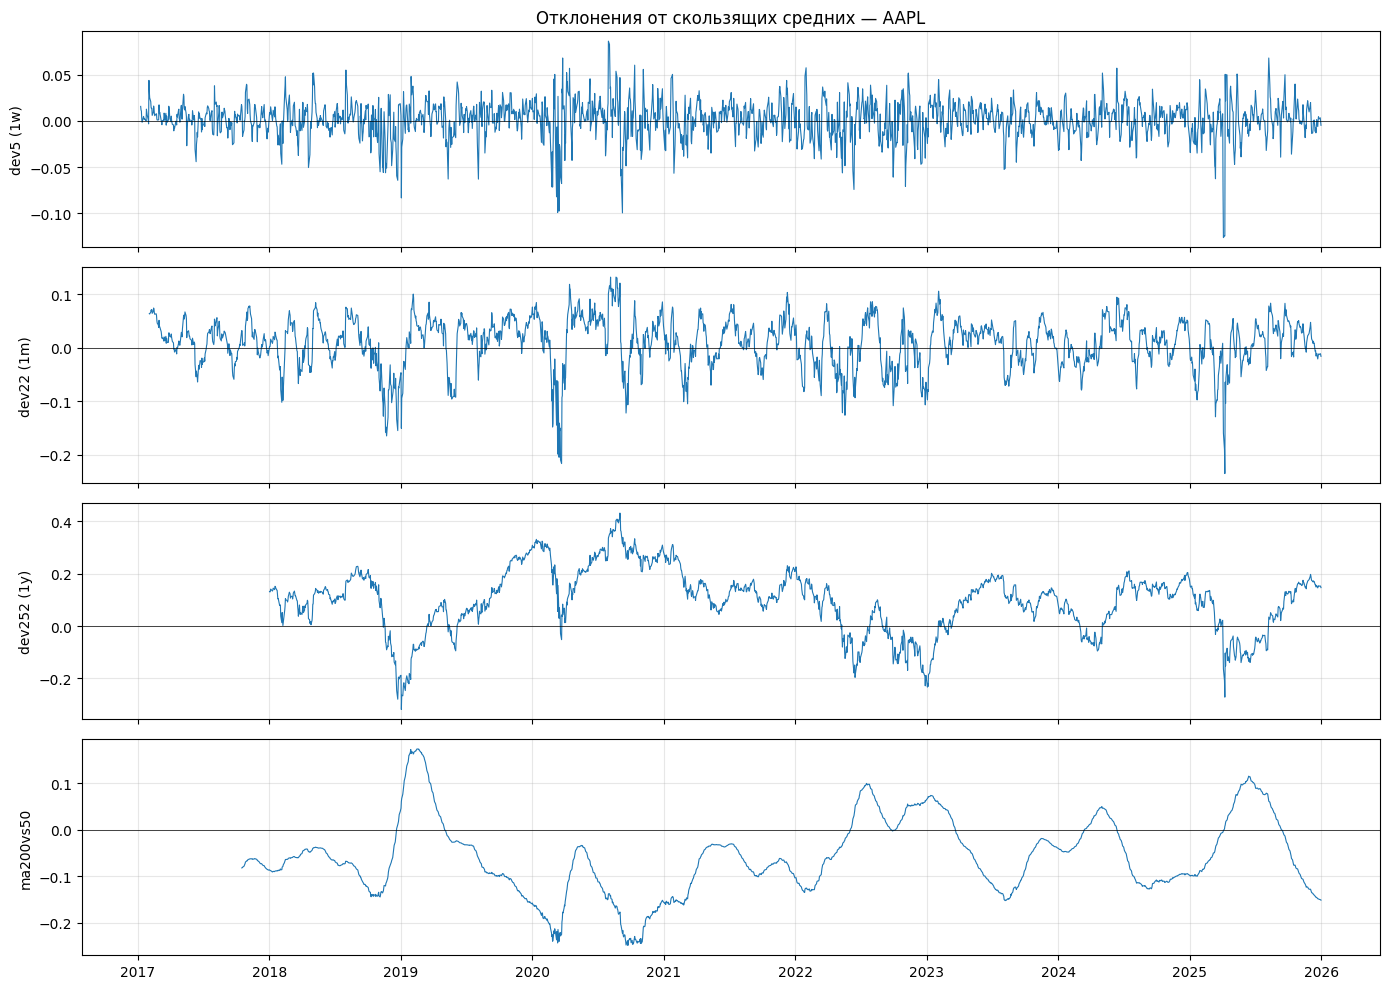

In [35]:
# визуализация
p = close[ticker].dropna()
dev5      = (p - p.rolling(5).mean())   / p
dev22     = (p - p.rolling(22).mean())  / p
dev252    = (p - p.rolling(252).mean()) / p
ma200vs50 = (p.rolling(200).mean() - p.rolling(50).mean()) / p

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, series, label in zip(axes,
        [dev5, dev22, dev252, ma200vs50],
        ["dev5 (1w)", "dev22 (1m)", "dev252 (1y)", "ma200vs50"]):
    ax.plot(series.index, series, linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel(label)
axes[0].set_title(f"Отклонения от скользящих средних — {ticker}")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

#### 2. Кросс-секционный импульс

Идея — **momentum**: бумаги, которые росли сильнее рынка на горизонте N дней, склонны продолжать обгонять.

Фича — это **ранг** доходности конкретной акции среди всех акций в портфеле на данную дату:

$$\text{mom}_n = \text{rank}\!\left(\frac{Close_t}{Close_{t-n}} - 1\right)_{\text{cross-section}}$$

- Ранги нормируют распределение и делают фичу устойчивой к выбросам.
- `mom5` — недельный, `mom22` — месячный импульс.
- `mom252` — **12-1 month momentum**: доходность за 12 месяцев *без последнего месяца* (`shift(22) / shift(252) - 1`). Последний месяц исключается, потому что на горизонте ~1 месяца работает краткосрочный реверсал, который загрязняет сигнал.

In [ ]:
def add_momentum(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет кросс-секционный ранг импульса (mom5, mom22, mom252)."""
    c = df["Close"]
    new = pd.concat({
        "mom5":   c.pct_change(5).rank(axis=1),
        "mom22":  c.pct_change(22).rank(axis=1),
        # 12-1 month: пропускаем последний месяц, чтобы убрать краткосрочный реверсал
        "mom252": (c.shift(22) / c.shift(252) - 1).rank(axis=1),
    }, axis=1)
    new.columns.names = ["Price", "Ticker"]
    df = pd.concat([df, new], axis=1).copy()
    df.to_csv(OUT_PATH)
    print(f"[add_momentum] +3 фичи → {OUT_PATH}  {df.shape}")
    return df


df = add_momentum(df)

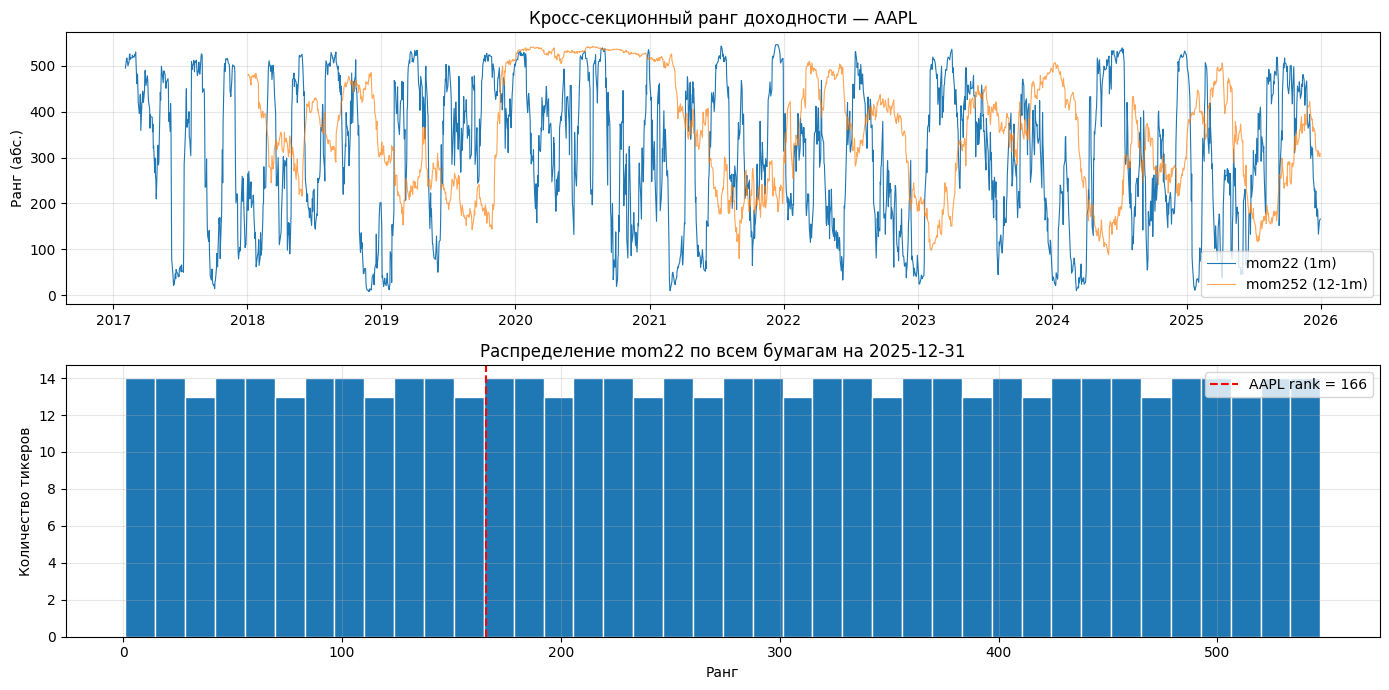

In [34]:
# визуализация
mom5   = close.pct_change(5).rank(axis=1)
mom22  = close.pct_change(22).rank(axis=1)
mom252 = (close.shift(22) / close.shift(252) - 1).rank(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))  # sharex убран: у осей разные типы

axes[0].plot(mom22.index, mom22[ticker], linewidth=0.8, label="mom22 (1m)")
axes[0].plot(mom252.index, mom252[ticker], linewidth=0.8, label="mom252 (12-1m)", alpha=0.7)
axes[0].set_ylabel("Ранг (абс.)")
axes[0].set_title(f"Кросс-секционный ранг доходности — {ticker}")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].legend()

last_date = mom22.dropna(how="all").index[-1]
axes[1].hist(mom22.loc[last_date].dropna(), bins=40, edgecolor="white")
axes[1].axvline(mom22.loc[last_date, ticker], color="red", linestyle="--",
                label=f"{ticker} rank = {mom22.loc[last_date, ticker]:.0f}")
axes[1].set_title(f"Распределение mom22 по всем бумагам на {last_date.date()}")
axes[1].set_xlabel("Ранг")
axes[1].set_ylabel("Количество тикеров")
axes[1].legend()

plt.tight_layout()
plt.show()

#### 3. Волатильность

Идея — волатильность доходностей как прокси **риска**: высоковолатильные бумаги могут иметь иное поведение, чем стабильные.

$$\text{vol}_n = \sigma_n(r_t), \quad r_t = \frac{Close_t}{Close_{t-1}} - 1$$

Считаем стандартное отклонение **дневных доходностей** на скользящем окне n дней. Это стандартная мера волатильности, сопоставимая между бумагами с разными уровнями цен.

- `vol5` — краткосрочная волатильность (1 неделя)
- `vol22` — среднесрочная (1 месяц)
- `vol252` — долгосрочная (1 год)

In [36]:
def add_volatility(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет std дневных доходностей на разных горизонтах (vol5, vol22, vol252)."""
    c = df["Close"]
    ret = c.pct_change()
    new = pd.concat({
        "vol5":   ret.rolling(5).std(),
        "vol22":  ret.rolling(22).std(),
        "vol252": ret.rolling(252).std(),
    }, axis=1)
    new.columns.names = ["Price", "Ticker"]
    df = pd.concat([df, new], axis=1).copy()
    df.to_csv(OUT_PATH)
    print(f"[add_volatility] +3 фичи → {OUT_PATH}  {df.shape}")
    return df


df = add_volatility(df)

[add_volatility] +3 фичи → equity_project/data/processed/all_data_features_extended.csv  (2262, 9299)


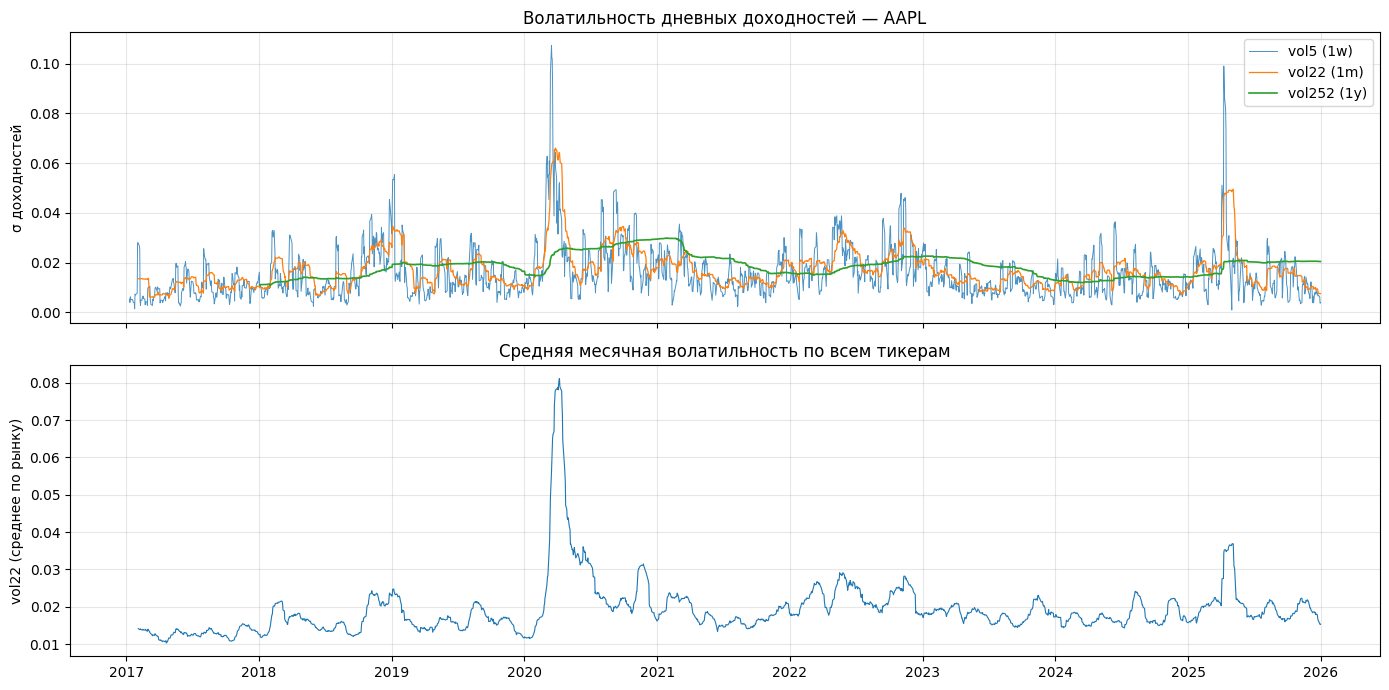

In [47]:
# визуализация
ret    = close.pct_change()
vol5   = ret.rolling(5).std()
vol22  = ret.rolling(22).std()
vol252 = ret.rolling(252).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(vol5[ticker].index,   vol5[ticker],   linewidth=0.7, label="vol5 (1w)",  alpha=0.8)
axes[0].plot(vol22[ticker].index,  vol22[ticker],  linewidth=0.9, label="vol22 (1m)")
axes[0].plot(vol252[ticker].index, vol252[ticker], linewidth=1.2, label="vol252 (1y)")
axes[0].set_ylabel("σ доходностей")
axes[0].set_title(f"Волатильность дневных доходностей — {ticker}")
axes[0].legend()

axes[1].plot(vol22.mean(axis=1).index, vol22.mean(axis=1), linewidth=0.8)
axes[1].set_ylabel("vol22 (среднее по рынку)")
axes[1].set_title("Средняя месячная волатильность по всем тикерам")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

#### 4. Рыночный режим

Три сигнала, одинаковые для всех тикеров на каждую дату — описывают контекст рынка.

- **`market_ret_22`** — медиана 22-дневных доходностей по кросс-секции. Положительный = рост рынка, отрицательный = падение.
- **`market_vol`** — std дневных доходностей по кросс-секции. Высокое значение = паника/кризис (аналог VIX).
- **`pct_above_200ma`** — доля акций выше своей 200-дневной MA. Показатель ширины рынка: ≥ 0.7 = здоровый тренд, ≤ 0.3 = медвежий рынок.

In [38]:
def add_market_regime(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет кросс-секционные индикаторы рыночного режима."""
    c = df["Close"]
    tickers = c.columns
    ret = c.pct_change()

    mkt_ret_22  = c.pct_change(22).median(axis=1)
    mkt_vol     = ret.std(axis=1)
    pct_above   = (c > c.rolling(200).mean()).mean(axis=1)

    def broadcast(series):
        return pd.DataFrame(
            np.tile(series.values[:, None], (1, len(tickers))),
            index=c.index, columns=tickers,
        )

    new = pd.concat({
        "market_ret_22":   broadcast(mkt_ret_22),
        "market_vol":      broadcast(mkt_vol),
        "pct_above_200ma": broadcast(pct_above),
    }, axis=1)
    new.columns.names = ["Price", "Ticker"]
    df = pd.concat([df, new], axis=1).copy()
    df.to_csv(OUT_PATH)
    print(f"[add_market_regime] +3 фичи → {OUT_PATH}  {df.shape}")
    return df

df = add_market_regime(df)

[add_market_regime] +3 фичи → equity_project/data/processed/all_data_features_extended.csv  (2262, 10940)


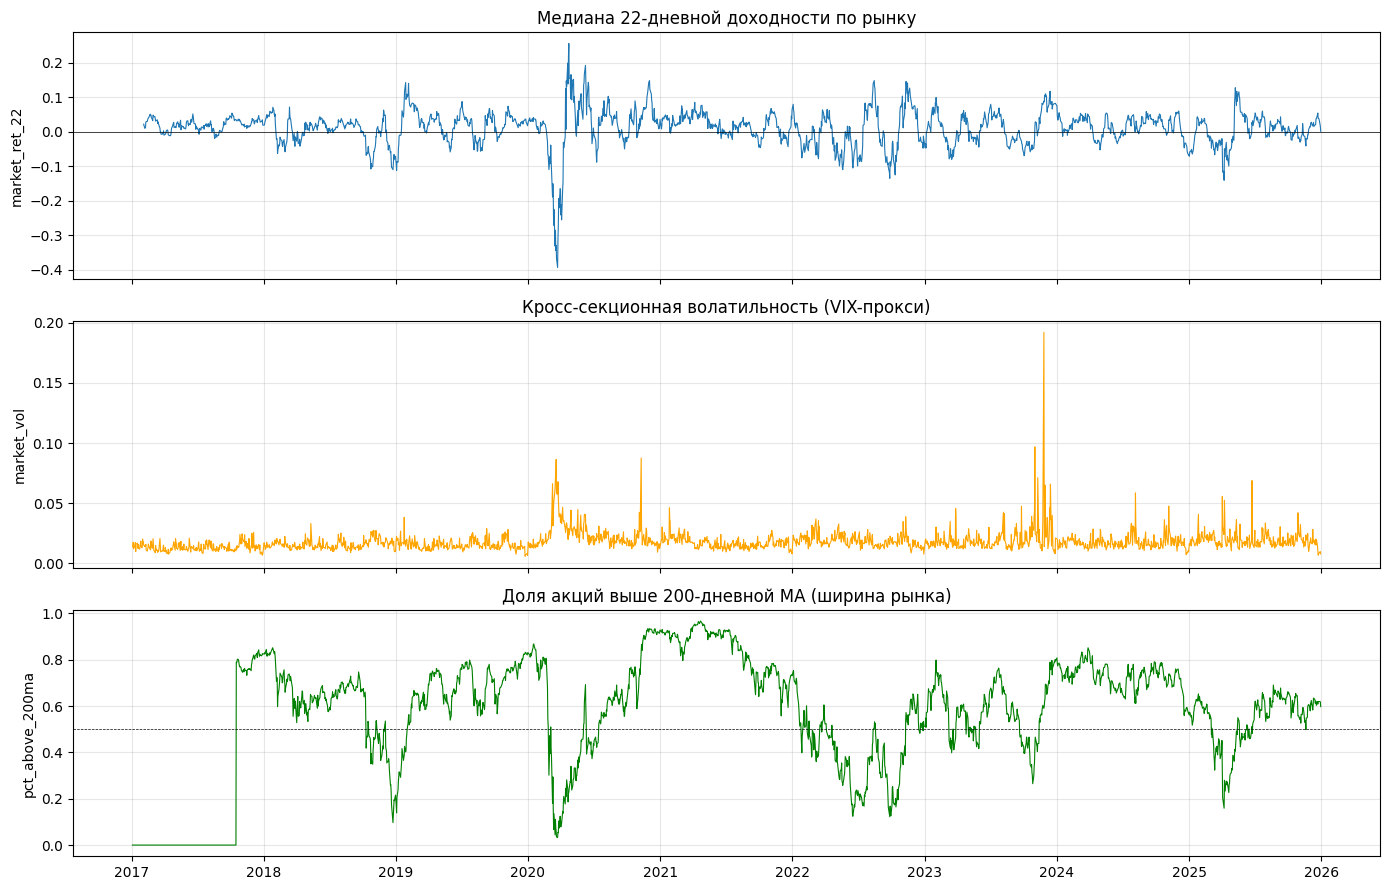

In [39]:
# визуализация
ret_viz     = close.pct_change()
mkt_ret_22  = close.pct_change(22).median(axis=1)
mkt_vol     = ret_viz.std(axis=1)
pct_above   = (close > close.rolling(200).mean()).mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(mkt_ret_22.index, mkt_ret_22, linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("market_ret_22")
axes[0].set_title("Медиана 22-дневной доходности по рынку")

axes[1].plot(mkt_vol.index, mkt_vol, linewidth=0.8, color="orange")
axes[1].set_ylabel("market_vol")
axes[1].set_title("Кросс-секционная волатильность (VIX-прокси)")

axes[2].plot(pct_above.index, pct_above, linewidth=0.8, color="green")
axes[2].axhline(0.5, color="black", linewidth=0.5, linestyle="--")
axes[2].set_ylabel("pct_above_200ma")
axes[2].set_title("Доля акций выше 200-дневной MA (ширина рынка)")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

#### 5. Краткосрочный реверсал и расстояние от 52-week high

- **`reversal`** = −pct_change(5): акции, упавшие за последнюю неделю, статистически чаще отскакивают. Знак минус делает сигнал «бычьим»: большое положительное значение → ожидаем рост.

$$\text{reversal} = -\frac{Close_t - Close_{t-5}}{Close_{t-5}}$$

- **`dist_52h`** = (Close − max(Close, 252)) / max(Close, 252): расстояние до 52-week high, всегда ≤ 0. Акции вблизи годового максимума (dist_52h ≈ 0) склонны продолжать рост — сильный momentum-сигнал.

$$\text{dist\_52h} = \frac{Close_t - \max_{252}(Close))}{\max_{252}(Close)}$$

In [40]:
def add_reversal_and_highs(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет краткосрочный реверсал и расстояние от 52-week high."""
    c = df["Close"]
    high_252 = c.rolling(252).max()
    new = pd.concat({
        "reversal": -c.pct_change(5),
        "dist_52h": (c - high_252) / high_252,
    }, axis=1)
    new.columns.names = ["Price", "Ticker"]
    df = pd.concat([df, new], axis=1).copy()
    df.to_csv(OUT_PATH)
    print(f"[add_reversal_and_highs] +2 фичи → {OUT_PATH}  {df.shape}")
    return df


df = add_reversal_and_highs(df)

[add_reversal_and_highs] +2 фичи → equity_project/data/processed/all_data_features_extended.csv  (2262, 12034)


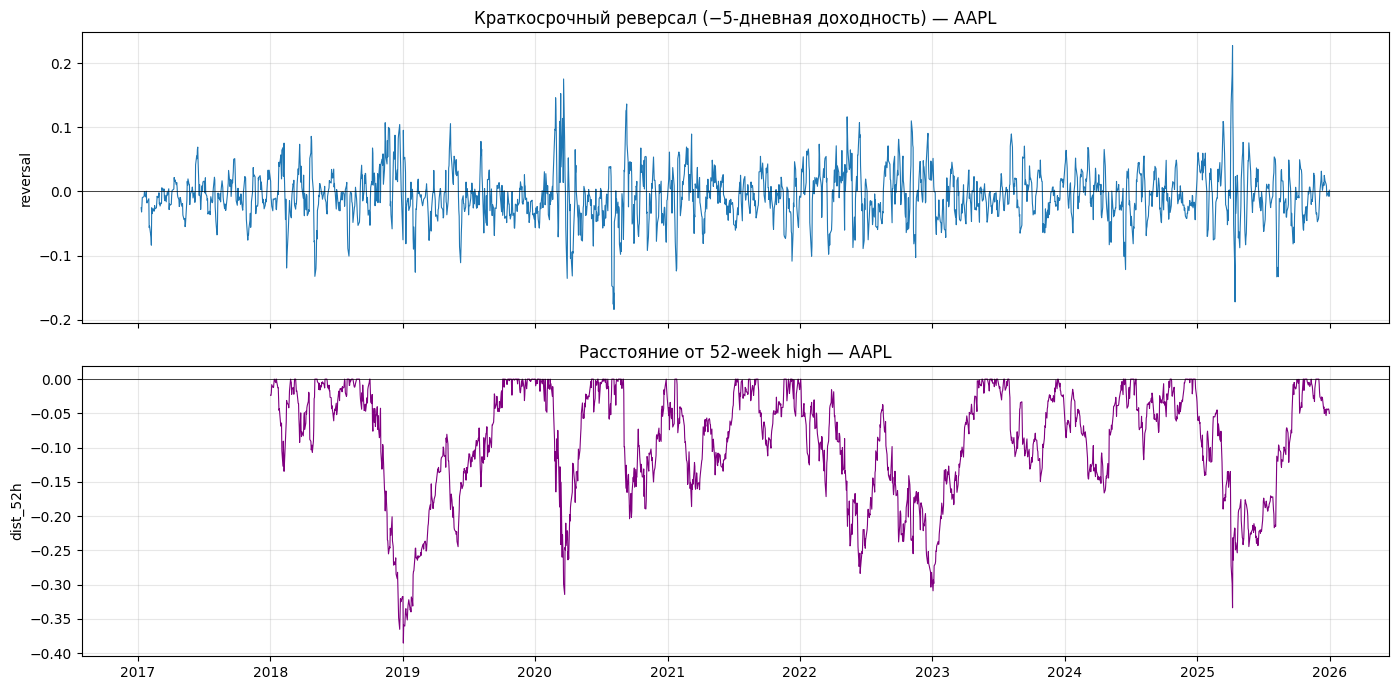

In [41]:
# визуализация
high_252 = close.rolling(252).max()
reversal = -close.pct_change(5)
dist_52h = (close - high_252) / high_252

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(reversal.index, reversal[ticker], linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("reversal")
axes[0].set_title(f"Краткосрочный реверсал (−5-дневная доходность) — {ticker}")

axes[1].plot(dist_52h.index, dist_52h[ticker], linewidth=0.8, color="purple")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("dist_52h")
axes[1].set_title(f"Расстояние от 52-week high — {ticker}")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

#### 6. Ликвидность

Прокси bid-ask спреда без доступа к стакану. Показывает, насколько сильно рынок двигается на единицу объёма.

$$\text{amihud} = \frac{1}{22}\sum_{s=t-21}^{t} \frac{|r_s|}{V_s}$$

- Высокое значение → неликвидная бумага, большие транзакционные издержки.
- Низкое значение → ликвидная бумага, узкий спред.

Высокая ликвидность важна для стратегии: неликвидные акции сложнее исполнять без влияния на цену.

In [42]:
def add_amihud(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет Amihud illiquidity: rolling 22-day mean(|ret| / volume)."""
    c = df["Close"]
    v = df["Volume"].replace(0, np.nan)
    amihud = (c.pct_change().abs() / v).rolling(22).mean()
    new = pd.concat({"amihud": amihud}, axis=1)
    new.columns.names = ["Price", "Ticker"]
    df = pd.concat([df, new], axis=1).copy()
    df.to_csv(OUT_PATH)
    print(f"[add_amihud] +1 фича → {OUT_PATH}  {df.shape}")
    return df


df = add_amihud(df)

[add_amihud] +1 фича → equity_project/data/processed/all_data_features_extended.csv  (2262, 12581)


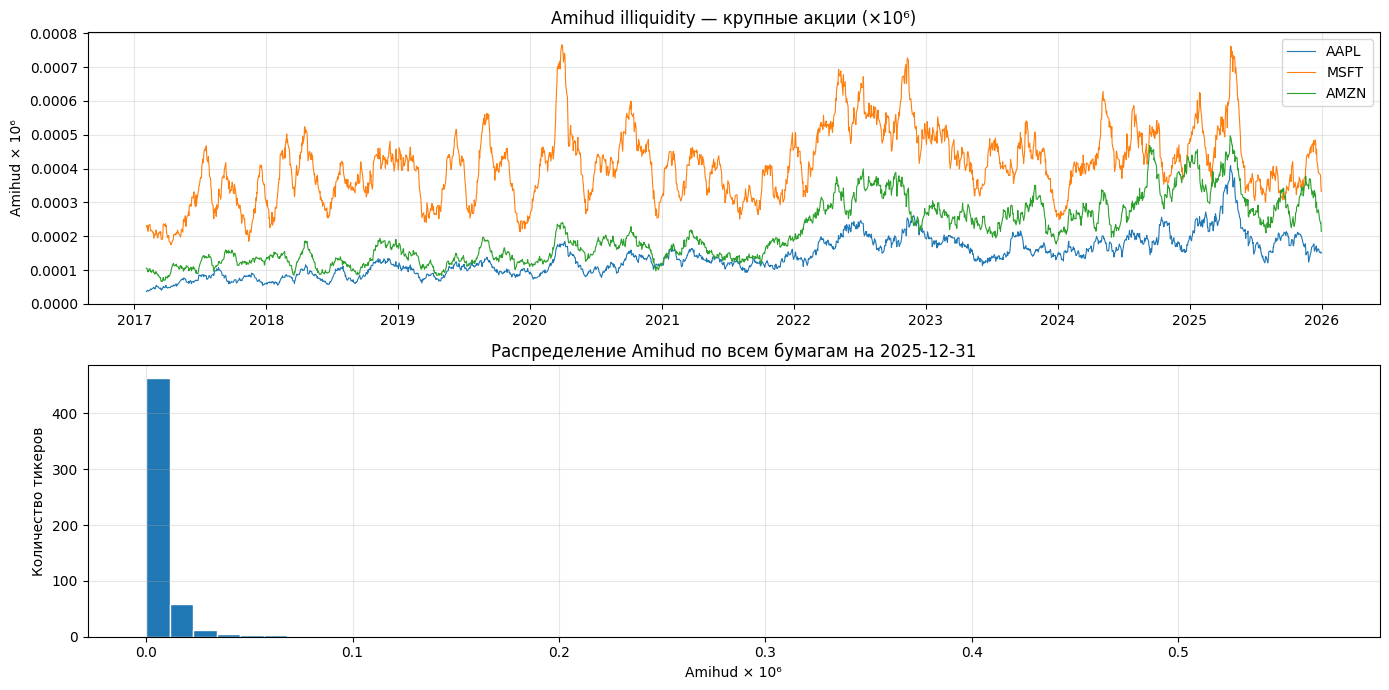

In [43]:
# визуализация
volume = df["Volume"].replace(0, np.nan)
amihud = (close.pct_change().abs() / volume).rolling(22).mean()

sample = ["AAPL", "MSFT", "AMZN"]
sample = [t for t in sample if t in amihud.columns]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(amihud.index, amihud[sample] * 1e6, linewidth=0.8)
axes[0].set_ylabel("Amihud × 10⁶")
axes[0].set_title("Amihud illiquidity — крупные акции (×10⁶)")
axes[0].legend(sample)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

last_date = amihud.dropna(how="all").index[-1]
axes[1].hist(amihud.loc[last_date].dropna() * 1e6, bins=50, edgecolor="white")
axes[1].set_xlabel("Amihud × 10⁶")
axes[1].set_ylabel("Количество тикеров")
axes[1].set_title(f"Распределение Amihud по всем бумагам на {last_date.date()}")

plt.tight_layout()
plt.show()

#### 7. Бета к рынку

Наклон регрессии дневных доходностей акции на среднюю доходность по кросс-секции за последние 60 дней.

$$\beta_t = \frac{\text{Cov}(r_i, r_m)_t}{\text{Var}(r_m)_t}, \quad r_m = \text{mean по всем тикерам}$$

- β > 1 → акция усиливает рыночные движения (агрессивная)
- β < 1 → защитная акция (утилиты, REIT)
- β < 0 → контртрендовая (редко)

Бета позволяет модели различать системный и идиосинкратический риск.

In [44]:
def add_beta(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет rolling 60-day бету к кросс-секционному среднему."""
    c = df["Close"]
    ret = c.pct_change()
    mkt = ret.mean(axis=1)  # прокси рыночной доходности

    window = 60
    mkt_var  = mkt.rolling(window).var()

    # Cov(r_i, r_m) = E[r_i * r_m] - E[r_i] * E[r_m]  — полностью векторизовано
    ri_rm = ret.multiply(mkt, axis=0)
    cov   = (ri_rm.rolling(window).mean()
             - ret.rolling(window).mean().multiply(mkt.rolling(window).mean(), axis=0))
    beta  = cov.divide(mkt_var, axis=0)

    new = pd.concat({"beta": beta}, axis=1)
    new.columns.names = ["Price", "Ticker"]
    df = pd.concat([df, new], axis=1).copy()
    df.to_csv(OUT_PATH)
    print(f"[add_beta] +1 фича → {OUT_PATH}  {df.shape}")
    return df


df = add_beta(df)

[add_beta] +1 фича → equity_project/data/processed/all_data_features_extended.csv  (2262, 13128)


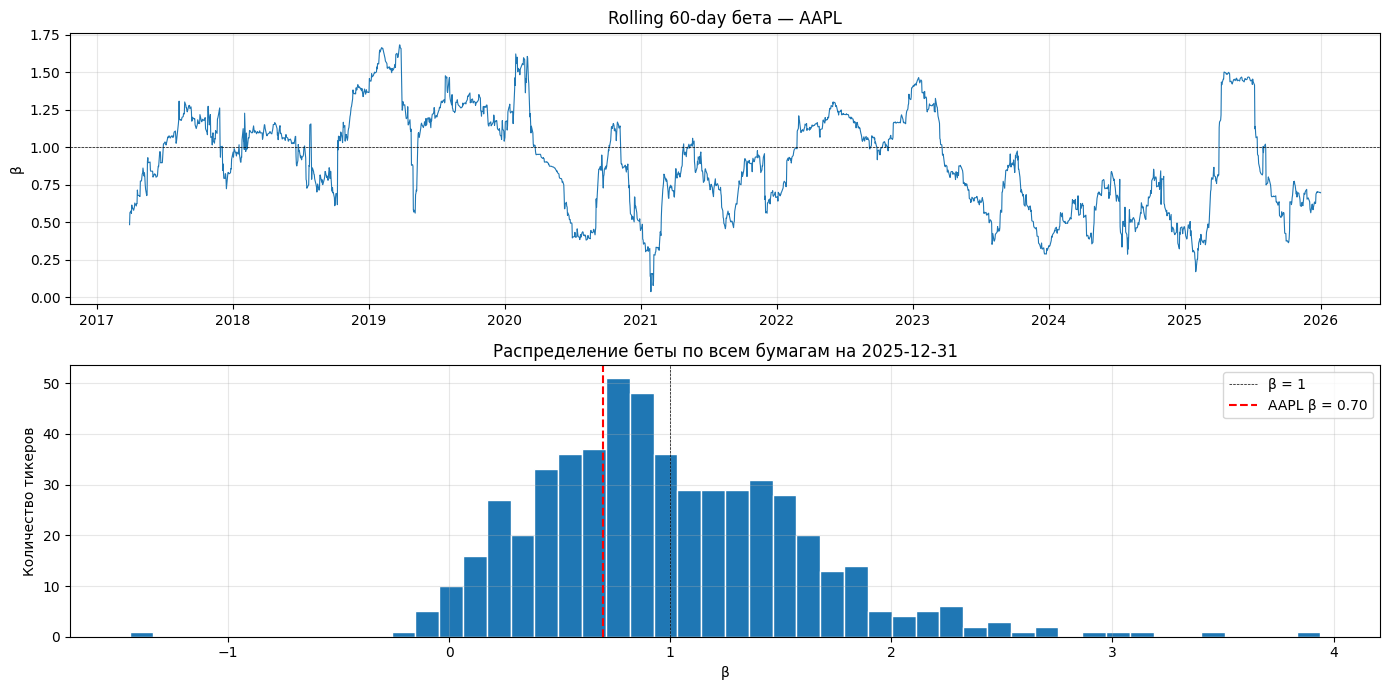

In [45]:
# визуализация
ret_viz  = close.pct_change()
mkt_viz  = ret_viz.mean(axis=1)
mkt_var  = mkt_viz.rolling(60).var()
ri_rm    = ret_viz.multiply(mkt_viz, axis=0)
cov      = (ri_rm.rolling(60).mean()
            - ret_viz.rolling(60).mean().multiply(mkt_viz.rolling(60).mean(), axis=0))
beta_viz = cov.divide(mkt_var, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(beta_viz.index, beta_viz[ticker], linewidth=0.8)
axes[0].axhline(1, color="black", linewidth=0.5, linestyle="--")
axes[0].set_ylabel("β")
axes[0].set_title(f"Rolling 60-day бета — {ticker}")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

last_date = beta_viz.dropna(how="all").index[-1]
axes[1].hist(beta_viz.loc[last_date].dropna(), bins=50, edgecolor="white")
axes[1].axvline(1, color="black", linewidth=0.5, linestyle="--", label="β = 1")
axes[1].axvline(beta_viz.loc[last_date, ticker], color="red", linestyle="--",
                label=f"{ticker} β = {beta_viz.loc[last_date, ticker]:.2f}")
axes[1].set_xlabel("β")
axes[1].set_ylabel("Количество тикеров")
axes[1].set_title(f"Распределение беты по всем бумагам на {last_date.date()}")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Итоговый список добавленных фичей

Все 17 фич сохранены в `all_data_features_extended.csv` как отдельные "price types" в MultiIndex-колонках. При обучении используется только эта часть датасета; OHLCV и таргеты хранятся там же для удобства.

| # | Фича | Формула / описание | Группа |
|---|---|---|---|
| 1 | `dev5` | (Close − MA₅) / Close | Mean reversion |
| 2 | `dev22` | (Close − MA₂₂) / Close | Mean reversion |
| 3 | `dev252` | (Close − MA₂₅₂) / Close | Mean reversion |
| 4 | `ma200vs50` | (MA₂₀₀ − MA₅₀) / Close | Mean reversion |
| 5 | `mom5` | rank(pct_change(5)) по кросс-секции | Momentum |
| 6 | `mom22` | rank(pct_change(22)) по кросс-секции | Momentum |
| 7 | `mom252` | rank(shift(22)/shift(252) − 1) — 12-1 month | Momentum |
| 8 | `vol5` | std(ret, 5) | Волатильность |
| 9 | `vol22` | std(ret, 22) | Волатильность |
| 10 | `vol252` | std(ret, 252) | Волатильность |
| 11 | `market_ret_22` | median(pct_change(22)) по всем тикерам | Рыночный режим |
| 12 | `market_vol` | std(ret) по кросс-секции на каждую дату | Рыночный режим |
| 13 | `pct_above_200ma` | доля акций выше своей MA₂₀₀ | Рыночный режим |
| 14 | `reversal` | −pct_change(5) | Краткосрочный реверсал |
| 15 | `dist_52h` | (Close − max(Close, 252)) / max(Close, 252) | Momentum |
| 16 | `amihud` | rolling_mean(|ret| / Volume, 22) | Ликвидность |
| 17 | `beta` | Cov(r_i, r_mkt, 60) / Var(r_mkt, 60) | Систематический риск |

In [46]:
df_final = pd.read_csv(
    "equity_project/data/processed/all_data_features_extended.csv",
    index_col=0,
    header=[0, 1],
)
df_final.index = pd.to_datetime(df_final.index)

price_types = df_final.columns.get_level_values("Price").unique().tolist()
n_tickers   = df_final.columns.get_level_values("Ticker").nunique()

print(f"Shape:       {df_final.shape}")
print(f"Тикеров:     {n_tickers}")
print(f"Дней:        {len(df_final)}")
print(f"Период:      {df_final.index.min().date()} — {df_final.index.max().date()}")
print(f"\nPrice types ({len(price_types)}):")
for pt in sorted(price_types):
    print(f"  {pt}")

Shape:       (2262, 13128)
Тикеров:     547
Дней:        2262
Период:      2017-01-03 — 2025-12-31

Price types (24):
  Close
  High
  Low
  Open
  Quintile
  TripleBarrier
  Volume
  amihud
  beta
  dev22
  dev252
  dev5
  dist_52h
  ma200vs50
  market_ret_22
  market_vol
  mom22
  mom252
  mom5
  pct_above_200ma
  reversal
  vol22
  vol252
  vol5


#### Приведение к тренировочному формату

Из `all_data_features_extended.csv` формируем датасеты для обучения и бэктеста:

1. **Отделяем фичи от OHLCV и таргетов** — берём только 17 расчётных колонок.
2. **Сдвигаем фичи на 1 день** (`shift(1)`) — чтобы на момент наблюдения `t` модель видела только данные, известные до `t`.
3. **Кропаем первые 260 строк** — cold start: статистики на окне 252 дня не вычислены.
4. **Выравниваем X и y** — убираем строки, где таргет NaN (последние 22 строки без форвардного окна).
5. **Переводим в длинный формат** `(Date, Ticker)` и **разбиваем** на train / backtest по датам из `config.yaml`.
6. **Сохраняем** в `equity_project/data/learning-dataset/` в формате parquet.

In [49]:
import yaml

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

TRAIN_START    = cfg["train_start_date"]
TRAIN_END      = cfg["train_end_date"]
BACKTEST_START = cfg["backtest_start_date"]
BACKTEST_END   = cfg["backtest_end_date"]

# ── загрузка ──────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "equity_project/data/processed/all_data_features_extended.csv",
    index_col=0,
    header=[0, 1],
)
df.index = pd.to_datetime(df.index)

all_price_types = df.columns.get_level_values("Price").unique().tolist()
OHLCV   = ["Close", "High", "Low", "Open", "Volume"]
TARGETS = ["TripleBarrier", "Quintile"]
FEATURES = [pt for pt in all_price_types if pt not in OHLCV + TARGETS]

print(f"Фич: {len(FEATURES)}: {FEATURES}")

# ── фичи: сдвиг на 1 день, кроп cold start ───────────────────────────────────
X_wide = df[FEATURES].shift(1).iloc[260:]

# ── таргеты: кроп на те же даты ───────────────────────────────────────────────
y_tb_wide = df["TripleBarrier"].loc[X_wide.index]
y_q_wide  = df["Quintile"].loc[X_wide.index]

# ── стек в длинный формат (Date, Ticker) ──────────────────────────────────────
X       = X_wide.stack(level=1).rename_axis(["Date", "Ticker"])
y_tb    = y_tb_wide.stack().rename("TripleBarrier").rename_axis(["Date", "Ticker"])
y_q     = y_q_wide.stack().rename("Quintile").rename_axis(["Date", "Ticker"])

# ── убираем строки где таргет NaN (последние n_days без форвардного окна) ──────
valid_tb = y_tb.dropna().index
valid_q  = y_q.dropna().index

X_tb = X.loc[X.index.intersection(valid_tb)]
X_q  = X.loc[X.index.intersection(valid_q)]
y_tb = y_tb.loc[valid_tb]
y_q  = y_q.loc[valid_q]

# ── сплит по датам ────────────────────────────────────────────────────────────
def split(df, start, end):
    d = df.index.get_level_values("Date")
    return df[(d >= start) & (d <= end)]

X_tb_train    = split(X_tb, TRAIN_START, TRAIN_END)
X_tb_backtest = split(X_tb, BACKTEST_START, BACKTEST_END)
X_q_train     = split(X_q,  TRAIN_START, TRAIN_END)
X_q_backtest  = split(X_q,  BACKTEST_START, BACKTEST_END)

y_tb_train    = split(y_tb.to_frame(), TRAIN_START, TRAIN_END)
y_tb_backtest = split(y_tb.to_frame(), BACKTEST_START, BACKTEST_END)
y_q_train     = split(y_q.to_frame(),  TRAIN_START, TRAIN_END)
y_q_backtest  = split(y_q.to_frame(),  BACKTEST_START, BACKTEST_END)

# ── сохранение ────────────────────────────────────────────────────────────────
out = Path("equity_project/data/learning-dataset")
out.mkdir(parents=True, exist_ok=True)

X_tb_train.to_parquet(out / "X_tb_train.parquet")
X_tb_backtest.to_parquet(out / "X_tb_backtest.parquet")
X_q_train.to_parquet(out / "X_q_train.parquet")
X_q_backtest.to_parquet(out / "X_q_backtest.parquet")

y_tb_train.to_parquet(out / "y_tb_train.parquet")
y_tb_backtest.to_parquet(out / "y_tb_backtest.parquet")
y_q_train.to_parquet(out / "y_q_train.parquet")
y_q_backtest.to_parquet(out / "y_q_backtest.parquet")

print(f"\nСохранено в {out}:")
for name, d in [
    ("X_tb_train",    X_tb_train),
    ("X_tb_backtest", X_tb_backtest),
    ("y_tb_train",    y_tb_train),
    ("y_tb_backtest", y_tb_backtest),
    ("X_q_train",     X_q_train),
    ("X_q_backtest",  X_q_backtest),
    ("y_q_train",     y_q_train),
    ("y_q_backtest",  y_q_backtest),
]:
    print(f"  {name+'.parquet':<25} {d.shape}")

Фич: 17: ['dev5', 'dev22', 'dev252', 'ma200vs50', 'mom5', 'mom22', 'mom252', 'vol5', 'vol22', 'vol252', 'market_ret_22', 'market_vol', 'pct_above_200ma', 'reversal', 'dist_52h', 'amihud', 'beta']

Сохранено в equity_project/data/learning-dataset:
  X_tb_train.parquet        (546453, 17)
  X_tb_backtest.parquet     (536607, 17)
  y_tb_train.parquet        (546453, 1)
  y_tb_backtest.parquet     (536607, 1)
  X_q_train.parquet         (546453, 17)
  X_q_backtest.parquet      (536607, 17)
  y_q_train.parquet         (546453, 1)
  y_q_backtest.parquet      (536607, 1)


## Обучение ML модели

### Обучение модели для Triple Barrier

#### Метрика

Задача — **3-классовая классификация**: short (−1), neutral (0), long (+1).

**Macro F1** — основная метрика:

$$F1_{\text{macro}} = \frac{1}{3}\sum_{c \in \{-1,0,1\}} \frac{2 \cdot \text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

Считает F1 для каждого класса отдельно и усредняет с **равными весами**. Модель, которая всегда говорит «нейтрал», получит F1 = 0 для long и short → macro F1 ≈ 0.17. Хорошая модель должна давать > 0.35.

Дополнительно смотрим на **confusion matrix** и **feature importance**.

#### Анализ распределения таргета

X_train: (546453, 17)
y_train: (546453,)
Фичи: ['dev5', 'dev22', 'dev252', 'ma200vs50', 'mom5', 'mom22', 'mom252', 'vol5', 'vol22', 'vol252', 'market_ret_22', 'market_vol', 'pct_above_200ma', 'reversal', 'dist_52h', 'amihud', 'beta']

Распределение классов:
  -1: 191,255  (35.0%)
  +0: 111,449  (20.4%)
  +1: 243,749  (44.6%)


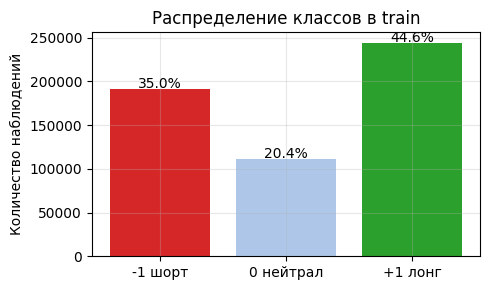

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ld = Path("equity_project/data/learning-dataset")

X_train = pd.read_parquet(ld / "X_tb_train.parquet")
y_train = pd.read_parquet(ld / "y_tb_train.parquet")["TripleBarrier"].astype(int)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Фичи: {X_train.columns.tolist()}")
print(f"\nРаспределение классов:")
vc = y_train.value_counts().sort_index()
for cls, cnt in vc.items():
    print(f"  {cls:+d}: {cnt:>7,}  ({cnt / len(y_train):.1%})")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["-1 шорт", "0 нейтрал", "+1 лонг"], vc.values,
       color=["#d62728", "#aec7e8", "#2ca02c"])
for bar, val in zip(ax.patches, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"{val / vc.sum():.1%}", ha="center", fontsize=10)
ax.set_title("Распределение классов в train")
ax.set_ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

#### Обучение и подбор гиперпараметров

In [62]:
from catboost import CatBoostClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score


def tscv_with_embargo(dates, n_splits=3, embargo_days=22):
    """TimeSeriesSplit по уникальным датам с embargo между фолдами."""
    unique_dates = np.sort(dates.unique())
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for d_train_idx, d_val_idx in tscv.split(unique_dates):
        last_train = pd.Timestamp(unique_dates[d_train_idx[-1]])
        cutoff     = last_train + pd.Timedelta(days=embargo_days)
        val_dates  = unique_dates[d_val_idx]
        val_dates  = val_dates[val_dates > np.datetime64(cutoff)]
        if len(val_dates) == 0:
            continue
        train_mask = dates.isin(unique_dates[d_train_idx])
        val_mask   = dates.isin(val_dates)
        yield np.where(train_mask)[0], np.where(val_mask)[0]


PARAM_GRID = [
    {"depth": 4, "learning_rate": 0.10, "l2_leaf_reg":  3},
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg":  3},
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 10},
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg":  5},
    {"depth": 6, "learning_rate": 0.10, "l2_leaf_reg":  3},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg":  3},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 10},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg":  5},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg":  3},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg": 10},
    {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg":  5},
]

dates  = X_train.index.get_level_values("Date")
splits = list(tscv_with_embargo(dates, n_splits=3, embargo_days=22))
print(f"CV фолдов: {len(splits)}")
for i, (tr, vl) in enumerate(splits):
    print(f"  fold {i+1}: train={len(tr):,}  val={len(vl):,}")

print("\nGrid search:")
gs_results = []
for params in PARAM_GRID:
    fold_scores = []
    for train_idx, val_idx in splits:
        model = CatBoostClassifier(
            loss_function="MultiClass",
            iterations=1000,
            early_stopping_rounds=30,
            thread_count=-1,
            random_seed=42,
            verbose=0,
            **params,
        )
        model.fit(
            X_train.iloc[train_idx], y_train.iloc[train_idx],
            eval_set=(X_train.iloc[val_idx], y_train.iloc[val_idx]),
        )
        preds = model.predict(X_train.iloc[val_idx]).ravel().astype(int)
        fold_scores.append(f1_score(y_train.iloc[val_idx], preds, average="macro"))

    row = {**params, "mean_f1": np.mean(fold_scores), "std_f1": np.std(fold_scores)}
    gs_results.append(row)
    print(f"  depth={params['depth']}, lr={params['learning_rate']:.2f}"
          f"  →  F1={row['mean_f1']:.4f} ± {row['std_f1']:.4f}")

gs_df = pd.DataFrame(gs_results).sort_values("mean_f1", ascending=False).reset_index(drop=True)
display(gs_df)

best = gs_df.iloc[0]
print(f"\nЛучшие параметры: depth={int(best['depth'])}, lr={best['learning_rate']}")

CV фолдов: 3
  fold 1: train=137,844  val=127,998
  fold 2: train=274,047  val=128,545
  fold 3: train=410,250  val=127,998

Grid search:
  depth=4, lr=0.10  →  F1=0.3542 ± 0.0332
  depth=4, lr=0.05  →  F1=0.3645 ± 0.0516
  depth=4, lr=0.05  →  F1=0.3645 ± 0.0516
  depth=4, lr=0.03  →  F1=0.3611 ± 0.0467
  depth=6, lr=0.10  →  F1=0.3635 ± 0.0434
  depth=6, lr=0.05  →  F1=0.3626 ± 0.0445
  depth=6, lr=0.05  →  F1=0.3625 ± 0.0449
  depth=6, lr=0.03  →  F1=0.3614 ± 0.0420
  depth=8, lr=0.05  →  F1=0.3575 ± 0.0363
  depth=8, lr=0.05  →  F1=0.3568 ± 0.0380
  depth=8, lr=0.03  →  F1=0.3629 ± 0.0428


,depth,learning_rate,l2_leaf_reg,mean_f1,std_f1
0,4,0.05,10,0.364544,0.051591
1,4,0.05,3,0.364465,0.051586
2,6,0.10,3,0.363515,0.043437
3,8,0.03,5,0.362917,0.042808
4,6,0.05,3,0.362646,0.044504
5,6,0.05,10,0.362525,0.044899
6,6,0.03,5,0.361426,0.041991
7,4,0.03,5,0.361104,0.046690
8,8,0.05,3,0.357525,0.036264
9,8,0.05,10,0.356771,0.037966



Лучшие параметры: depth=4, lr=0.05


In [63]:
import joblib

# Последние 15% уникальных дат — holdout для early stopping финальной модели
unique_dates  = np.sort(X_train.index.get_level_values("Date").unique())
n_holdout     = max(1, int(len(unique_dates) * 0.15))
holdout_start = pd.Timestamp(unique_dates[-n_holdout])

final_train_mask = X_train.index.get_level_values("Date") < holdout_start
final_eval_mask  = X_train.index.get_level_values("Date") >= holdout_start

print(f"Final train: {final_train_mask.sum():,} строк  "
      f"({X_train[final_train_mask].index.get_level_values('Date').nunique()} дат)")
print(f"Final eval:  {final_eval_mask.sum():,} строк  "
      f"({X_train[final_eval_mask].index.get_level_values('Date').nunique()} дат)")

model_tb = CatBoostClassifier(
    loss_function="MultiClass",
    depth=int(best["depth"]),
    learning_rate=float(best["learning_rate"]),
    iterations=2000,
    early_stopping_rounds=50,
    thread_count=-1,
    random_seed=42,
    verbose=100,
)

model_tb.fit(
    X_train[final_train_mask], y_train[final_train_mask],
    eval_set=(X_train[final_eval_mask], y_train[final_eval_mask]),
)

models_dir = Path("equity_project/models")
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(model_tb, models_dir / "model_tb.joblib")
print(f"\nМодель сохранена → {models_dir / 'model_tb.joblib'}")
print(f"Лучшая итерация: {model_tb.best_iteration_}")

Final train: 464,950 строк  (850 дат)
Final eval:  81,503 строк  (149 дат)
0:	learn: 1.0895366	test: 1.0929761	best: 1.0929761 (0)	total: 53.1ms	remaining: 1m 46s
100:	learn: 0.9409590	test: 1.0151308	best: 1.0151308 (100)	total: 3.41s	remaining: 1m 4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.014153812
bestIteration = 115

Shrink model to first 116 iterations.

Модель сохранена → equity_project/models/model_tb.joblib
Лучшая итерация: 115


Macro F1 (holdout): 0.4424

              precision    recall  f1-score   support

  short (−1)       0.45      0.37      0.41     29470
 neutral (0)       0.43      0.36      0.39     18130
   long (+1)       0.48      0.59      0.53     33903

    accuracy                           0.46     81503
   macro avg       0.45      0.44      0.44     81503
weighted avg       0.46      0.46      0.45     81503



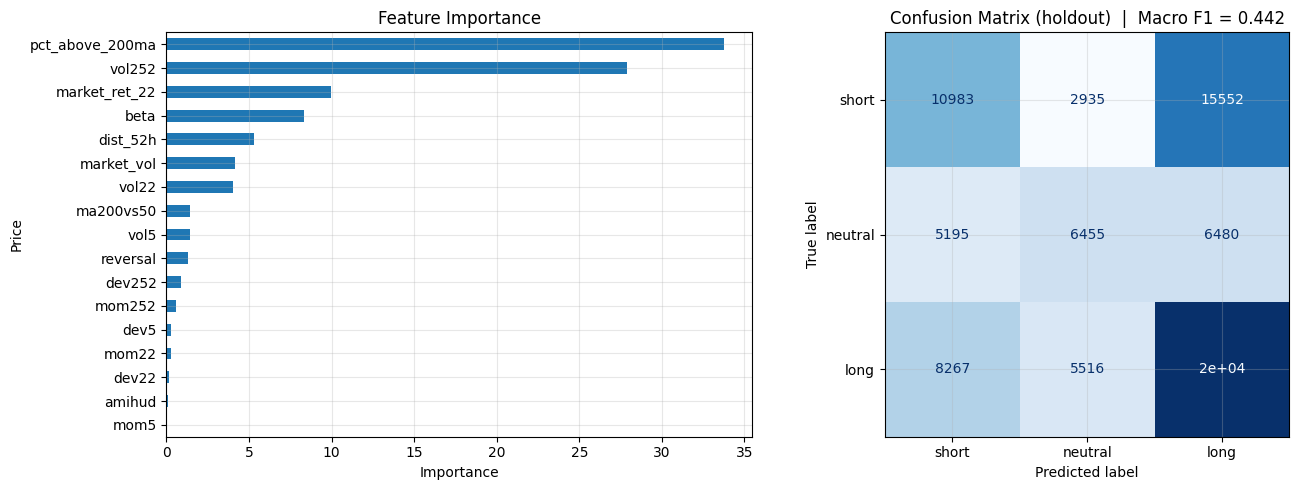

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

preds_eval = model_tb.predict(X_train[final_eval_mask]).ravel().astype(int)
y_eval     = y_train[final_eval_mask]

macro_f1 = f1_score(y_eval, preds_eval, average="macro")
print(f"Macro F1 (holdout): {macro_f1:.4f}\n")
print(classification_report(y_eval, preds_eval,
                             target_names=["short (−1)", "neutral (0)", "long (+1)"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- feature importance ---
feat_imp = pd.Series(
    model_tb.get_feature_importance(),
    index=X_train.columns,
).sort_values()
feat_imp.plot(kind="barh", ax=axes[0])
axes[0].set_title("Feature Importance")
axes[0].set_xlabel("Importance")

# --- confusion matrix ---
cm = confusion_matrix(y_eval, preds_eval, labels=[-1, 0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["short", "neutral", "long"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix (holdout)  |  Macro F1 = {macro_f1:.3f}")

plt.tight_layout()
plt.show()

### Обучение модели для квинтиля доходности

#### Метрика

Задача — **регрессия квинтиля доходности**: предсказываем номер квинтиля (1–5) форвардной 22-дневной доходности.

**IC (Information Coefficient)** — основная метрика:

$$IC = \frac{1}{T} \sum_{t=1}^{T} \rho\!\left(\hat{y}_t,\, y_t\right)$$

где $\rho$ — коэффициент корреляции Пирсона, вычисляемый **по всем бумагам** в день $t$.

IC измеряет, насколько хорошо ранжирование предсказаний совпадает с ранжированием реальных доходностей. IC = 0 — нет предсказательной силы, IC > 0.05 считается хорошим для финансовых данных.

Дополнительно смотрим на **feature importance** и **violin plot** предсказаний по истинным квинтилям.

#### Анализ распределения таргета

X_train_q: (546453, 17)
y_train_q: (546453,)
Фичи: ['dev5', 'dev22', 'dev252', 'ma200vs50', 'mom5', 'mom22', 'mom252', 'vol5', 'vol22', 'vol252', 'market_ret_22', 'market_vol', 'pct_above_200ma', 'reversal', 'dist_52h', 'amihud', 'beta']

Распределение квинтилей:
  Q1.0: 108,884  (19.9%)
  Q2.0: 108,911  (19.9%)
  Q3.0: 109,856  (20.1%)
  Q4.0: 108,916  (19.9%)
  Q5.0: 109,886  (20.1%)


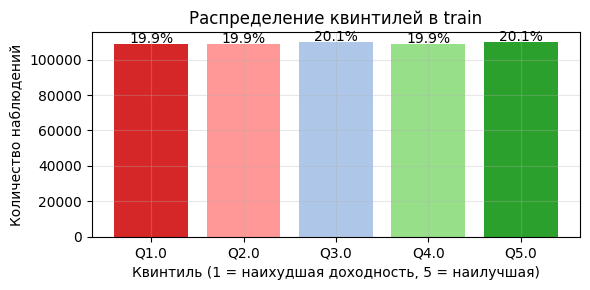

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ld = Path("equity_project/data/learning-dataset")

X_train_q = pd.read_parquet(ld / "X_q_train.parquet")
y_train_q  = pd.read_parquet(ld / "y_q_train.parquet")["Quintile"]

print(f"X_train_q: {X_train_q.shape}")
print(f"y_train_q: {y_train_q.shape}")
print(f"Фичи: {X_train_q.columns.tolist()}")
print(f"\nРаспределение квинтилей:")
vc = y_train_q.value_counts().sort_index()
for cls, cnt in vc.items():
    print(f"  Q{cls}: {cnt:>7,}  ({cnt / len(y_train_q):.1%})")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([f"Q{i}" for i in vc.index], vc.values,
       color=["#d62728", "#ff9896", "#aec7e8", "#98df8a", "#2ca02c"])
for bar, val in zip(ax.patches, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"{val / vc.sum():.1%}", ha="center", fontsize=10)
ax.set_title("Распределение квинтилей в train")
ax.set_ylabel("Количество наблюдений")
ax.set_xlabel("квантиль (1 = наихудшая доходность, 5 = наилучшая)")
plt.tight_layout()
plt.show()

#### Обучение и подбор гиперпараметров

In [66]:
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit


def tscv_with_embargo(dates, n_splits=3, embargo_days=22):
    """TimeSeriesSplit по уникальным датам с embargo между фолдами."""
    unique_dates = np.sort(dates.unique())
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for d_train_idx, d_val_idx in tscv.split(unique_dates):
        last_train = pd.Timestamp(unique_dates[d_train_idx[-1]])
        cutoff     = last_train + pd.Timedelta(days=embargo_days)
        val_dates  = unique_dates[d_val_idx]
        val_dates  = val_dates[val_dates > np.datetime64(cutoff)]
        if len(val_dates) == 0:
            continue
        train_mask = dates.isin(unique_dates[d_train_idx])
        val_mask   = dates.isin(val_dates)
        yield np.where(train_mask)[0], np.where(val_mask)[0]


def compute_ic(y_true: pd.Series, y_pred) -> float:
    """Mean per-date Pearson correlation между предсказаниями и таргетом."""
    df = pd.DataFrame({"pred": y_pred, "true": y_true.values},
                      index=y_true.index)
    per_date = df.groupby(level="Date").apply(
        lambda g: g["pred"].corr(g["true"])
    )
    return per_date.mean()


PARAM_GRID = [
    {"depth": 4, "learning_rate": 0.10, "l2_leaf_reg":  3},
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg":  3},
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 10},
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg":  5},
    {"depth": 6, "learning_rate": 0.10, "l2_leaf_reg":  3},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg":  3},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 10},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg":  5},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg":  3},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg": 10},
    {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg":  5},
]

dates_q = X_train_q.index.get_level_values("Date")
splits_q = list(tscv_with_embargo(dates_q, n_splits=3, embargo_days=22))
print(f"CV фолдов: {len(splits_q)}")
for i, (tr, vl) in enumerate(splits_q):
    print(f"  fold {i+1}: train={len(tr):,}  val={len(vl):,}")

print("\nGrid search:")
gs_results_q = []
for params in PARAM_GRID:
    fold_scores = []
    for train_idx, val_idx in splits_q:
        model = CatBoostRegressor(
            loss_function="RMSE",
            iterations=1000,
            early_stopping_rounds=30,
            thread_count=-1,
            random_seed=42,
            verbose=0,
            **params,
        )
        model.fit(
            X_train_q.iloc[train_idx], y_train_q.iloc[train_idx],
            eval_set=(X_train_q.iloc[val_idx], y_train_q.iloc[val_idx]),
        )
        preds = model.predict(X_train_q.iloc[val_idx])
        fold_scores.append(compute_ic(y_train_q.iloc[val_idx], preds))

    row = {**params, "mean_ic": np.mean(fold_scores), "std_ic": np.std(fold_scores)}
    gs_results_q.append(row)
    print(f"  depth={params['depth']}, lr={params['learning_rate']:.2f}"
          f"  →  IC={row['mean_ic']:.4f} ± {row['std_ic']:.4f}")

gs_df_q = pd.DataFrame(gs_results_q).sort_values("mean_ic", ascending=False).reset_index(drop=True)
display(gs_df_q)

best_q = gs_df_q.iloc[0]
print(f"\nЛучшие параметры: depth={int(best_q['depth'])}, lr={best_q['learning_rate']}")

CV фолдов: 3
  fold 1: train=137,844  val=127,998
  fold 2: train=274,047  val=128,545
  fold 3: train=410,250  val=127,998

Grid search:
  depth=4, lr=0.10  →  IC=0.0155 ± 0.0096
  depth=4, lr=0.05  →  IC=0.0097 ± 0.0125
  depth=4, lr=0.05  →  IC=0.0098 ± 0.0126
  depth=4, lr=0.03  →  IC=0.0066 ± 0.0118
  depth=6, lr=0.10  →  IC=0.0217 ± 0.0201
  depth=6, lr=0.05  →  IC=0.0101 ± 0.0231
  depth=6, lr=0.05  →  IC=0.0093 ± 0.0229
  depth=6, lr=0.03  →  IC=0.0107 ± 0.0126
  depth=8, lr=0.05  →  IC=0.0120 ± 0.0212
  depth=8, lr=0.05  →  IC=0.0099 ± 0.0208
  depth=8, lr=0.03  →  IC=0.0148 ± 0.0129


,depth,learning_rate,l2_leaf_reg,mean_ic,std_ic
0,6,0.10,3,0.021731,0.020113
1,4,0.10,3,0.015497,0.009557
2,8,0.03,5,0.014769,0.012886
3,8,0.05,3,0.011961,0.021170
4,6,0.03,5,0.010688,0.012567
5,6,0.05,3,0.010123,0.023137
6,8,0.05,10,0.009895,0.020764
7,4,0.05,10,0.009842,0.012584
8,4,0.05,3,0.009743,0.012524
9,6,0.05,10,0.009278,0.022907



Лучшие параметры: depth=6, lr=0.1


In [67]:
import joblib

# Последние 15% уникальных дат — holdout для early stopping финальной модели
unique_dates_q  = np.sort(X_train_q.index.get_level_values("Date").unique())
n_holdout_q     = max(1, int(len(unique_dates_q) * 0.15))
holdout_start_q = pd.Timestamp(unique_dates_q[-n_holdout_q])

final_train_mask_q = X_train_q.index.get_level_values("Date") < holdout_start_q
final_eval_mask_q  = X_train_q.index.get_level_values("Date") >= holdout_start_q

print(f"Final train: {final_train_mask_q.sum():,} строк  "
      f"({X_train_q[final_train_mask_q].index.get_level_values('Date').nunique()} дат)")
print(f"Final eval:  {final_eval_mask_q.sum():,} строк  "
      f"({X_train_q[final_eval_mask_q].index.get_level_values('Date').nunique()} дат)")

model_q = CatBoostRegressor(
    loss_function="RMSE",
    depth=int(best_q["depth"]),
    learning_rate=float(best_q["learning_rate"]),
    iterations=2000,
    early_stopping_rounds=50,
    thread_count=-1,
    random_seed=42,
    verbose=100,
)

model_q.fit(
    X_train_q[final_train_mask_q], y_train_q[final_train_mask_q],
    eval_set=(X_train_q[final_eval_mask_q], y_train_q[final_eval_mask_q]),
)

models_dir = Path("equity_project/models")
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(model_q, models_dir / "model_q.joblib")
print(f"\nМодель сохранена → {models_dir / 'model_q.joblib'}")
print(f"Лучшая итерация: {model_q.best_iteration_}")

Final train: 464,950 строк  (850 дат)
Final eval:  81,503 строк  (149 дат)
0:	learn: 1.4120676	test: 1.4144791	best: 1.4144791 (0)	total: 21.3ms	remaining: 42.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.414479079
bestIteration = 0

Shrink model to first 1 iterations.

Модель сохранена → equity_project/models/model_q.joblib
Лучшая итерация: 0


IC (holdout): -0.0168


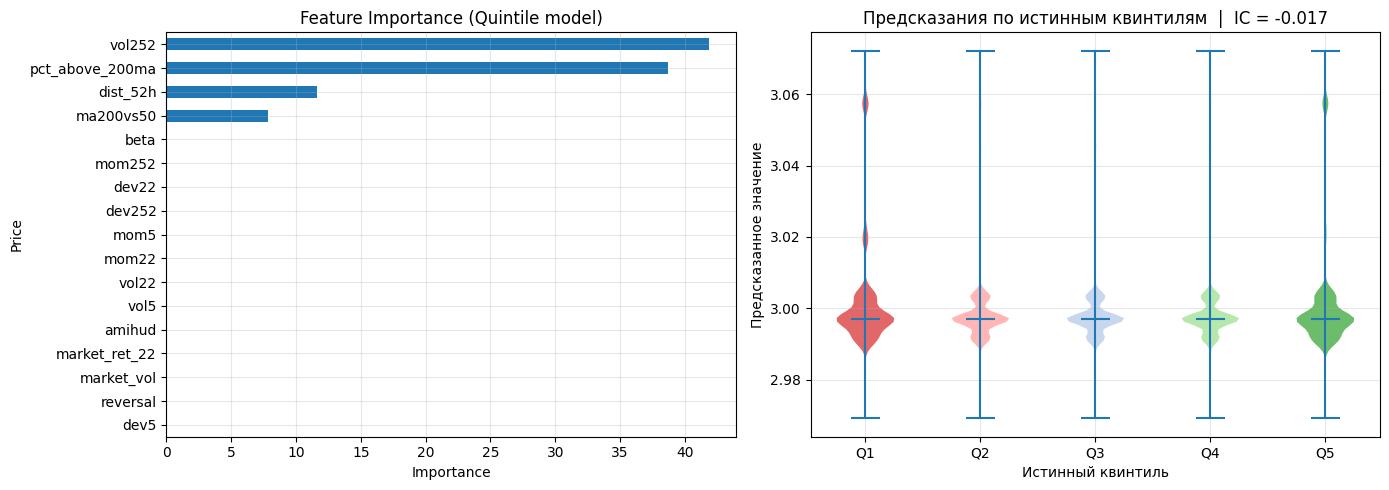

In [68]:
preds_eval_q = model_q.predict(X_train_q[final_eval_mask_q])
y_eval_q     = y_train_q[final_eval_mask_q]

holdout_ic = compute_ic(y_eval_q, preds_eval_q)
print(f"IC (holdout): {holdout_ic:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- feature importance ---
feat_imp_q = pd.Series(
    model_q.get_feature_importance(),
    index=X_train_q.columns,
).sort_values()
feat_imp_q.plot(kind="barh", ax=axes[0])
axes[0].set_title("Feature Importance (Quintile model)")
axes[0].set_xlabel("Importance")

# --- violin plot: pred distribution per true quintile ---
df_eval = pd.DataFrame({"pred": preds_eval_q, "true_q": y_eval_q.values})
quintile_groups = [df_eval.loc[df_eval["true_q"] == q, "pred"].values for q in range(1, 6)]
vp = axes[1].violinplot(quintile_groups, positions=range(1, 6), showmedians=True)
colors = ["#d62728", "#ff9896", "#aec7e8", "#98df8a", "#2ca02c"]
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)
axes[1].set_xticks(range(1, 6))
axes[1].set_xticklabels([f"Q{i}" for i in range(1, 6)])
axes[1].set_xlabel("Истинный квантиль")
axes[1].set_ylabel("Предсказанное значение")
axes[1].set_title(f"Предсказания по истинным квинтилям  |  IC = {holdout_ic:.3f}")

plt.tight_layout()
plt.show()

### Инференс на бектесте

In [69]:
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

ld = Path("equity_project/data/learning-dataset")
models_dir = Path("equity_project/models")

# Загружаем модели
model_tb = joblib.load(models_dir / "model_tb.joblib")
model_q  = joblib.load(models_dir / "model_q.joblib")

# Загружаем бэктест-фичи
X_bt_tb = pd.read_parquet(ld / "X_tb_backtest.parquet")
X_bt_q  = pd.read_parquet(ld / "X_q_backtest.parquet")

print(f"X_bt_tb: {X_bt_tb.shape}")
print(f"X_bt_q:  {X_bt_q.shape}")
print(f"Дат в бэктесте: {X_bt_tb.index.get_level_values('Date').nunique()}")
print(f"Бумаг в бэктесте: {X_bt_tb.index.get_level_values('Ticker').nunique()}")

X_bt_tb: (536607, 17)
X_bt_q:  (536607, 17)
Дат в бэктесте: 981
Бумаг в бэктесте: 547


In [70]:
# --- Triple Barrier: вероятности трёх классов ---
proba_tb = model_tb.predict_proba(X_bt_tb)  # (N, 3)
classes  = model_tb.classes_.astype(int)     # [-1, 0, 1]
col_map  = {-1: 'prob_short', 0: 'prob_neutral', 1: 'prob_long'}

df_tb = pd.DataFrame(
    proba_tb,
    index=X_bt_tb.index,
    columns=[col_map[c] for c in classes],
)
df_tb['pred_tb'] = model_tb.predict(X_bt_tb).ravel().astype(int)

# --- Quintile: предсказанный квантиль ---
df_tb['pred_q'] = model_q.predict(X_bt_q)

# --- net-сигнал TB: P(long) - P(short) ---
df_tb['net_signal'] = df_tb['prob_long'] - df_tb['prob_short']

print(df_tb.head(10).to_string())
print(f'\nИтого строк: {len(df_tb):,}')
print(f'Распределение pred_tb:')
print(df_tb['pred_tb'].value_counts().sort_index())

                   prob_short  prob_neutral  prob_long  pred_tb    pred_q  net_signal
Date       Ticker                                                                    
2022-01-03 A         0.321538      0.400323   0.278140        0  2.991756   -0.043398
           AAL       0.514399      0.069194   0.416407       -1  2.991756   -0.097992
           AAP       0.397089      0.294668   0.308243       -1  2.996970   -0.088846
           AAPL      0.347529      0.356670   0.295802        0  2.996970   -0.051727
           ABBV      0.263804      0.507873   0.228322        0  2.996970   -0.035482
           ABT       0.281069      0.477038   0.241893        0  2.996970   -0.039176
           ACGL      0.350833      0.394361   0.254805        0  2.996970   -0.096028
           ACN       0.367692      0.378627   0.253681        0  2.996970   -0.114012
           ADBE      0.470304      0.164188   0.365508       -1  2.991756   -0.104796
           ADI       0.389095      0.265507   0.345398

In [71]:
out_path = ld / 'predictions_backtest.parquet'
df_tb.to_parquet(out_path)
print(f'Сохранено → {out_path}')
print(f'Колонки: {df_tb.columns.tolist()}')
print(f'Индекс: {df_tb.index.names}')

Сохранено → equity_project/data/learning-dataset/predictions_backtest.parquet
Колонки: ['prob_short', 'prob_neutral', 'prob_long', 'pred_tb', 'pred_q', 'net_signal']
Индекс: ['Date', 'Ticker']


## Стратегия на основе предсказанных таргетов

#### Идея

Стратегия — **ML-driven long-only equity** на акциях из исторического состава S&P 500. Каждые $K$ торговых дней портфель пересматривается на основе сигналов двух ML-моделей.

#### Источники сигнала

| Модель | Что предсказывает | Как используется |
|--------|-------------------|------------------|
| **Triple Barrier** (CatBoost Classifier) | Вероятности short / neutral / long для каждой бумаги | `net_signal = P(long) − P(short)` — мера «бычьей» уверенности модели |
| **Quintile** (CatBoost Regressor) | квантиль форвардной 22-дневной доходности (1–5) | Усилитель: бумаги с высоким `pred_q` получают бо́льший вес |

#### Итоговый score

$$\text{score}_i = \underbrace{(P_i^{\text{long}} - P_i^{\text{short}})}_{\text{TB net-signal}} \times \underbrace{\hat{q}_i}_{\text{quintile}}$$

Перемножение дает высокий score только бумагам, которые **обе** модели считают привлекательными.

#### Отбор и взвешивание

1. **Фильтр**: оставляем только бумаги с `score > 0` (TB-модель ожидает рост)
2. **Веса**: пропорциональны score — чем выше уверенность, тем больше доля
3. **Нормировка**: веса суммируются в 1 (fully invested, без плеча)

$$w_i = \frac{\text{score}_i}{\sum_{j:\, \text{score}_j > 0} \text{score}_j}$$

#### Исполнение и ребалансировка

- Сигнал формируется на **закрытии дня $T$** на основе фич, вычисленных по данным до $T-1$
- Сделки исполняются по **цене Open дня $T+1$** — нет подглядывания в будущее
- Ребалансировка происходит каждые **$K$ торговых дней** (параметр)
- Комиссия: **0.1%** от оборота на каждую сделку

#### Параметр $K$

| $K$ | Характер | Плюсы | Минусы |
|-----|----------|-------|--------|
| 1 | Ежедневный | Самые свежие сигналы | Высокий оборот, комиссии |
| 5 | Еженедельный | Баланс актуальности и издержек | — |
| 22 | Ежемесячный | Минимальные комиссии | Сигналы устаревают |

In [2]:
import numpy as np
import pandas as pd
import vectorbt as vbt
from pathlib import Path

ld = Path("equity_project/data/learning-dataset")

# ── параметры ──────────────────────────────────────────────────────────
K          = 5      # частота ребалансировки (торговых дней)
INIT_CASH  = 20_000_000
FEES       = 0.001
# ───────────────────────────────────────────────────────────────────────

import yaml
with open('config.yaml') as _f:
    _cfg = yaml.safe_load(_f)
BT_START = pd.Timestamp(_cfg['backtest_start_date'])
BT_END   = pd.Timestamp(_cfg['backtest_end_date'])

# Загружаем предсказания и цены исполнения
preds = pd.read_parquet(ld / "predictions_backtest.parquet")
all_data = pd.read_csv(
    "equity_project/data/processed/all_data_features_extended.csv",
    index_col=0, header=[0, 1],
    parse_dates=True,
)
all_data.index = pd.to_datetime(all_data.index)
all_data.index.name = 'Date'

# Фильтруем строго по диапазону бэктеста из config.yaml
bt_mask  = (preds.index.get_level_values('Date') >= BT_START) & \
           (preds.index.get_level_values('Date') <= BT_END)
preds    = preds[bt_mask]
bt_dates = preds.index.get_level_values('Date').unique().sort_values()

# Цена исполнения — Open следующего дня
# shift(-1) делаем ДО фильтрации, чтобы последняя дата бэктеста
# взяла Open следующего торгового дня из all_data (а не NaN)
tickers = preds.index.get_level_values('Ticker').unique()
open_prices = (
    all_data['Open'][tickers]
    .shift(-1)                          # исполнение на следующий Open
    .loc[bt_dates]                      # только даты бэктеста
    .dropna(how='all')                  # убираем строки без цен
)
# Убираем экстремальные дневные изменения цены (>±50%) — признак битых данных
daily_ratio = open_prices / open_prices.shift(1)
open_prices = open_prices.where((daily_ratio >= 0.5) & (daily_ratio <= 2.0), other=np.nan)
open_prices = open_prices.ffill()
print(f'Диапазон бэктеста: {open_prices.index[0].date()} → {open_prices.index[-1].date()}')

# ── формируем score и веса ──────────────────────────────────────────────
# Разворачиваем предсказания в wide-формат (Date × Ticker)
net_signal = preds['net_signal'].unstack('Ticker').reindex(columns=tickers)
pred_q     = preds['pred_q'].unstack('Ticker').reindex(columns=tickers)

score = net_signal * pred_q
score[score <= 0] = 0          # фильтруем неположительный сигнал

# Выравниваем open_prices и score по общим датам и тикерам
common_dates   = score.index.intersection(open_prices.index)
common_tickers = score.columns.intersection(open_prices.columns)
score       = score.loc[common_dates, common_tickers]
open_prices = open_prices.loc[common_dates, common_tickers]
# Снимаем имена индексов — vectorbt требует их совпадения
open_prices.index.name = None
open_prices.columns.name = None

# Ребалансировка каждые K дней: в промежуточные дни повторяем веса
dates = score.index
rebal_mask = np.zeros(len(dates), dtype=bool)
rebal_mask[::K] = True

weights = score.div(score.sum(axis=1).replace(0, np.nan), axis=0)  # нормировка
weights = weights.where(pd.Series(rebal_mask, index=dates), other=np.nan)
weights = weights.ffill()    # в не-ребалансировочные дни держим предыдущие веса
weights = weights.reindex_like(open_prices).fillna(0)

print(f'Дат в бэктесте:   {len(dates)}')
print(f'Ребалансировок:   {rebal_mask.sum()}')
print(f'Среднее кол-во позиций в день ребалансировки: '
      f'{(weights > 0).sum(axis=1)[rebal_mask].mean():.0f}')
print(f'Макс. вес одной бумаги: {weights.max().max():.3f}')
print(f'open_prices shape: {open_prices.shape}, weights shape: {weights.shape}')

Диапазон бэктеста: 2022-01-03 → 2025-11-28
Дат в бэктесте:   981
Ребалансировок:   197
Среднее кол-во позиций в день ребалансировки: 426
Макс. вес одной бумаги: 0.928
open_prices shape: (981, 547), weights shape: (981, 547)


In [3]:
# ── бэктест через vectorbt ─────────────────────────────────────────────
pf = vbt.Portfolio.from_orders(
    close=open_prices,
    size=weights,
    size_type='targetpercent',
    init_cash=INIT_CASH,
    fees=FEES,
    freq='1D',
    group_by=True,
    cash_sharing=True,
)

stats = pf.stats()
print(stats.to_string())

Start                                2022-01-03 00:00:00
End                                  2025-11-28 00:00:00
Period                                 981 days 00:00:00
Start Value                                   20000000.0
End Value                                24637243.597127
Total Return [%]                               23.186218
Benchmark Return [%]                           36.909637
Max Gross Exposure [%]                             100.0
Total Fees Paid                           2251743.531177
Max Drawdown [%]                               25.444906
Max Drawdown Duration                  507 days 00:00:00
Total Trades                                      207622
Total Closed Trades                               207075
Total Open Trades                                    547
Open Trade PnL                             165923.731277
Win Rate [%]                                   54.281299
Best Trade [%]                                  280.0702
Worst Trade [%]                

CAGR:         5.5%
Sharpe:       0.33
Max Drawdown: -25.4%
Calmar:       0.22


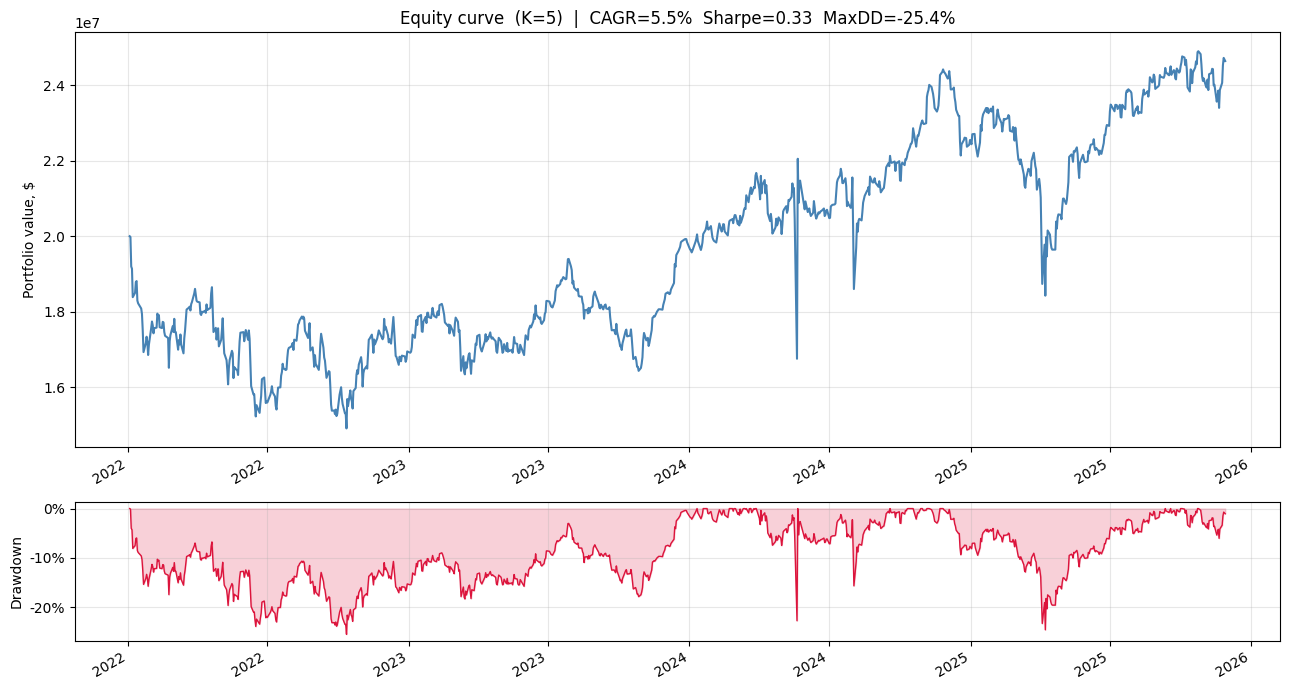

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Считаем метрики
rets   = pf.returns()
equity = pf.value()

total_ret  = equity.iloc[-1] / equity.iloc[0] - 1
n_years    = (equity.index[-1] - equity.index[0]).days / 365.25
cagr       = (1 + total_ret) ** (1 / n_years) - 1
sharpe     = rets.mean() / rets.std() * np.sqrt(252)
max_dd     = (equity / equity.cummax() - 1).min()
calmar     = cagr / abs(max_dd)

print(f'CAGR:         {cagr:.1%}')
print(f'Sharpe:       {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.1%}')
print(f'Calmar:       {calmar:.2f}')

fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={'height_ratios': [3, 1]})

# equity curve
equity.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title(f'Equity curve  (K={K})  |  CAGR={cagr:.1%}  Sharpe={sharpe:.2f}  MaxDD={max_dd:.1%}')
axes[0].set_ylabel('Portfolio value, $')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(alpha=0.3)

# drawdown
dd = equity / equity.cummax() - 1
dd.plot(ax=axes[1], color='crimson', linewidth=1)
axes[1].fill_between(dd.index, dd, 0, color='crimson', alpha=0.2)
axes[1].set_ylabel('Drawdown')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

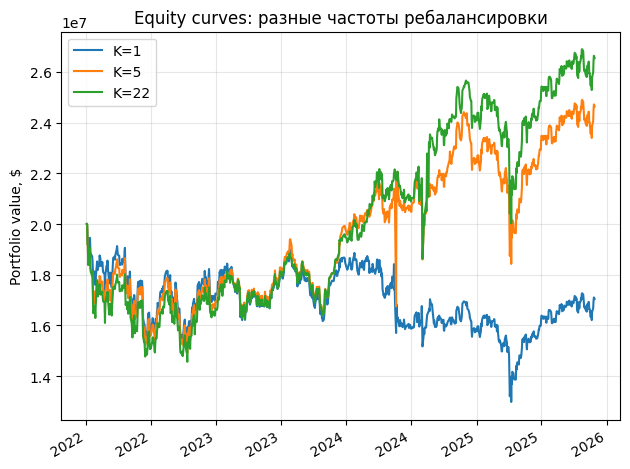

,CAGR,Sharpe,Max DD,Calmar
K,,,,
1,-4.0%,-0.09,-35.1%,-0.11
5,5.5%,0.33,-25.4%,0.22
22,7.5%,0.43,-27.2%,0.28


In [5]:
# ── сравнение K=1, 5, 22 ──────────────────────────────────────────────
results = []
for k in [1, 5, 22]:
    rebal_mask_k = np.zeros(len(dates), dtype=bool)
    rebal_mask_k[::k] = True

    w = score.div(score.sum(axis=1).replace(0, np.nan), axis=0)
    w = w.where(pd.Series(rebal_mask_k, index=dates), other=np.nan)
    w = w.ffill().reindex_like(open_prices).fillna(0)

    pf_k = vbt.Portfolio.from_orders(
        close=open_prices,
        size=w,
        size_type='targetpercent',
        init_cash=INIT_CASH,
        fees=FEES,
        freq='1D',
        group_by=True,
        cash_sharing=True,
    )

    eq_k   = pf_k.value()
    ret_k  = pf_k.returns()
    tr     = eq_k.iloc[-1] / eq_k.iloc[0] - 1
    ny     = (eq_k.index[-1] - eq_k.index[0]).days / 365.25
    cagr_k = (1 + tr) ** (1 / ny) - 1
    sh_k   = ret_k.mean() / ret_k.std() * np.sqrt(252)
    dd_k   = (eq_k / eq_k.cummax() - 1).min()
    results.append({'K': k, 'CAGR': cagr_k, 'Sharpe': sh_k, 'Max DD': dd_k,
                    'Calmar': cagr_k / abs(dd_k)})

    eq_k.plot(label=f'K={k}', linewidth=1.5)

df_compare = pd.DataFrame(results).set_index('K')
df_compare['CAGR']   = df_compare['CAGR'].map('{:.1%}'.format)
df_compare['Sharpe'] = df_compare['Sharpe'].map('{:.2f}'.format)
df_compare['Max DD'] = df_compare['Max DD'].map('{:.1%}'.format)
df_compare['Calmar'] = df_compare['Calmar'].map('{:.2f}'.format)

plt.title('Equity curves: разные частоты ребалансировки')
plt.ylabel('Portfolio value, $')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(df_compare)

### Анализ результатов

| K | CAGR | Sharpe | Max DD | Calmar |
|---|------|--------|--------|--------|
| 1 (ежедневно) | −4.0% | −0.09 | −35.1% | −0.11 |
| 5 (еженедельно) | +5.5% | 0.33 | −25.4% | 0.22 |
| 22 (ежемесячно) | +7.5% | 0.43 | −27.2% | 0.28 |

#### Главный вывод: транзакционные издержки убивают высокочастотную ребалансировку

**K=1** даёт CAGR = −4% — стратегия убыточна. При ежедневной ребалансировке ~500 бумаг комиссии (0.1% × оборот × ~250 раз в год) полностью поглощают alpha модели. Это классический результат в систематической торговле: даже хорошая модель не спасает при избыточном обороте.

**K=5 и K=22** показывают положительный результат. CAGR 5.5–7.5% при Sharpe 0.33–0.43 — скромно, но сопоставимо с S&P 500 за тот же период (2022–2025 включал медвежий рынок 2022 и AI-ралли 2023–2024, итоговый CAGR индекса ~6–8%).